# Validaciones de Scanpaths — Hybrid Metadata

**Sección 1**: Validación del flujo completo de construcción de scanpaths (3 casos testigo).

**Sección 2**: Comparación entre `hybrid_metadata/human_scanpaths` y `Datasets/HSEM/human_scanpaths`.

In [2]:
import pandas as pd
import json
import numpy as np
import glob
from pathlib import Path

HYBRID_ROOT   = Path('../hybrid_metadata')
OUTPUT_DIR    = HYBRID_ROOT / 'output'
SCANPATHS_HYB = HYBRID_ROOT / 'human_scanpaths'
SCANPATHS_HSEM = Path('../Datasets/HSEM/human_scanpaths')
ITEM_POS_PATH = HYBRID_ROOT / 'item_pos.csv'

item_pos = pd.read_csv(ITEM_POS_PATH)
bbox_lookup = {
    row['stm']: {'pos_x': row['pos_x'], 'pos_y': row['pos_y'],
                 'height': row['height'], 'width': row['width']}
    for _, row in item_pos.iterrows()
}

def parse_stim(raw):
    if pd.isna(raw): return None
    name = str(raw).split('/')[-1]
    return None if name == 'blank.png' else name

def build_trial_info(bh):
    info = []
    for i in range(len(bh) // 6):
        row0 = bh.iloc[i * 6]
        row5 = bh.iloc[i * 6 + 5]
        target_stim = parse_stim(row0['st5'])
        memory_set  = [s for col in ['st1','st2','st3','st4','st5']
                        if (s := parse_stim(row0[col])) is not None]
        info.append({
            'image':          row0['searchimage'],
            'target_stim':    target_stim,
            'target_present': str(row0['st5_cat']) == 'T' and target_stim is not None,
            'target_found':   bool(row5['key_resp.corr'] == 1.0),
            'memory_set':     memory_set,
            'mss':            int(row0['Nstim']) if pd.notna(row0['Nstim']) else None,
        })
    return info

print('Setup OK')

Setup OK


---
## 1. Validación del flujo de construcción (3 casos testigo)

Muestra el flujo completo: `bh_data` → filtros CSV → `item_pos` → entrada JSON final.

Se eligen 3 trials de S101: uno por cada MSS (1, 2, 4), todos con `present=True`.

In [3]:
SUBJECT_VAL  = 'S101'
df_val = pd.read_csv(OUTPUT_DIR / f'{SUBJECT_VAL}_full_metadata.csv')
bh_val = pd.read_csv(glob.glob(f'../hybrid_metadata/UBA/{SUBJECT_VAL}/101_hybrid_search_builder_code_*.csv')[0],
                     encoding='utf-8-sig')
trial_info_val = build_trial_info(bh_val)

fix_val = df_val[
    (df_val['type']    == 'fixation') &
    (df_val['phase']   == 'vs')       &
    (df_val['bad']     == 0)          &
    (df_val['inrange'] == True)       &
    (df_val['present'] == True)
].sort_values(['trial', 'latency'])

# Un trial por MSS
casos = {}
for mss_target in [1, 2, 4]:
    for trial_id, tdf in fix_val.groupby('trial'):
        idx = int(trial_id) - 1
        if idx >= len(trial_info_val): continue
        info = trial_info_val[idx]
        if info['mss'] == mss_target and info['target_present']:
            casos[mss_target] = trial_id
            break

print('Trials seleccionados:')
for mss, tid in casos.items():
    info = trial_info_val[int(tid) - 1]
    print(f'  MSS={mss}  → trial {int(tid):3d}  |  {info["image"]}  |  target: {info["target_stim"]}')

Trials seleccionados:
  MSS=1  → trial   1  |  cmp_shelves_059_toys_018.jpg  |  target: truck196.png
  MSS=2  → trial  14  |  cmp_field_008_farmanimals_008.jpg  |  target: sheep580.png
  MSS=4  → trial   2  |  cmp_building_030_person_016.jpg  |  target: person1967.png


In [4]:
def show_case(trial_id, label):
    idx  = int(trial_id) - 1
    info = trial_info_val[idx]
    t_df = fix_val[fix_val['trial'] == trial_id]
    row0 = bh_val.iloc[idx * 6]
    row5 = bh_val.iloc[idx * 6 + 5]

    print('=' * 65)
    print(f'  CASO: {label}  |  Trial {int(trial_id)}  |  MSS={info["mss"]}  |  {SUBJECT_VAL}')
    print('=' * 65)

    print('\n── 1. bh_data (log PsychoPy) ──────────────────────────────')
    print(f'  searchimage  : {row0["searchimage"]}')
    print(f'  st1-st5      : {[row0[c] for c in ["st1","st2","st3","st4","st5"]]}')
    print(f'  st5_cat      : {row0["st5_cat"]}  (T=presente, A=ausente)')
    print(f'  key_resp.corr: {row5["key_resp.corr"]}  (1=correcto, 0=incorrecto)')

    print('\n── 2. Extraído por build_trial_info() ──────────────────────')
    print(f'  image         : {info["image"]}')
    print(f'  target_stim   : {info["target_stim"]}')
    print(f'  target_present: {info["target_present"]}')
    print(f'  target_found  : {info["target_found"]}')
    print(f'  memory_set    : {info["memory_set"]}')

    print('\n── 3. item_pos.csv → target_bbox ───────────────────────────')
    if info['target_stim'] and info['target_stim'] in bbox_lookup:
        b = bbox_lookup[info['target_stim']]
        bbox = [b['pos_y'], b['pos_x'], b['pos_y'] + b['height'], b['pos_x'] + b['width']]
        print(f'  pos_y={b["pos_y"]}, pos_x={b["pos_x"]}, h={b["height"]}, w={b["width"]}')
        print(f'  target_bbox   : {bbox}  → [y_min, x_min, y_max, x_max]')
    else:
        print(f'  [ALERT] target "{info["target_stim"]}" no encontrado en item_pos.csv')

    print('\n── 4. output CSV → fijaciones filtradas ────────────────────')
    print(f'  Total fijaciones: {len(t_df)}')
    print(t_df[['latency','fix_avgpos_x','fix_avgpos_y','ontarget','ondistractor','stm']]
          .to_string(index=False))

    print('\n── 5. Entrada final en el JSON ─────────────────────────────')
    print(f'  n_fijaciones  : {len(t_df)}')
    print(f'  X             : {t_df["fix_avgpos_x"].tolist()}')
    print(f'  Y             : {t_df["fix_avgpos_y"].tolist()}')
    print()

for mss, tid in casos.items():
    show_case(tid, f'MSS={mss}')

  CASO: MSS=1  |  Trial 1  |  MSS=1  |  S101

── 1. bh_data (log PsychoPy) ──────────────────────────────
  searchimage  : cmp_shelves_059_toys_018.jpg
  st1-st5      : ['memstim/blank.png', 'memstim/blank.png', 'memstim/blank.png', 'memstim/blank.png', 'memstim/truck196.png']
  st5_cat      : T  (T=presente, A=ausente)
  key_resp.corr: 1.0  (1=correcto, 0=incorrecto)

── 2. Extraído por build_trial_info() ──────────────────────
  image         : cmp_shelves_059_toys_018.jpg
  target_stim   : truck196.png
  target_present: True
  target_found  : True
  memory_set    : ['truck196.png']

── 3. item_pos.csv → target_bbox ───────────────────────────
  pos_y=84, pos_x=598, h=49, w=80
  target_bbox   : [84, 598, 133, 678]  → [y_min, x_min, y_max, x_max]

── 4. output CSV → fijaciones filtradas ────────────────────
  Total fijaciones: 6
 latency  fix_avgpos_x  fix_avgpos_y ontarget ondistractor               stm
 54055.0    799.259033    481.756317    False         True motorcycle116.png
 541

---
## 2. Comparación: `hybrid_metadata` vs `HSEM` scanpaths

Analiza las diferencias entre los scanpaths nuevos (Damián) y los originales (HSEM)
para los sujetos en común.

In [5]:
# Sujetos disponibles en ambas fuentes
# hybrid_metadata: IDs como '117969'; HSEM: IDs como 'et_117969' → normalizar quitando 'et_'
hyb_subjects  = {f.stem.replace('_scanpaths', '') for f in SCANPATHS_HYB.glob('*_scanpaths.json')}
hsem_raw      = {f.stem.replace('_scanpaths', '') for f in SCANPATHS_HSEM.glob('*_scanpaths.json')}
hsem_id_map   = {s.replace('et_', ''): s for s in hsem_raw}   # '117969' → 'et_117969'
hsem_subjects = set(hsem_id_map.keys())
common        = sorted(hyb_subjects & hsem_subjects)

print(f'Sujetos en hybrid_metadata : {len(hyb_subjects)}')
print(f'Sujetos en HSEM            : {len(hsem_raw)}')
print(f'En común (id normalizado)  : {len(common)}')
print(f'Solo en hybrid_metadata    : {sorted(hyb_subjects - hsem_subjects)}')
print(f'Solo en HSEM               : {sorted(hsem_subjects - hyb_subjects)}')

Sujetos en hybrid_metadata : 45
Sujetos en HSEM            : 44
En común (id normalizado)  : 39
Solo en hybrid_metadata    : ['123082', '159640', '573661', '629959', '664304', '719396']
Solo en HSEM               : ['123082_2', '629959_2', '664304_2', 'S110', 'S112']


In [6]:
# Comparación por sujeto: imágenes, fijaciones, target_found
rows = []
for subj in common:
    with open(SCANPATHS_HYB  / f'{subj}_scanpaths.json') as f:            sp_hyb  = json.load(f)
    with open(SCANPATHS_HSEM / f'{hsem_id_map[subj]}_scanpaths.json') as f: sp_hsem = json.load(f)

    imgs_hyb  = set(sp_hyb.keys())
    imgs_hsem = set(sp_hsem.keys())
    common_imgs = imgs_hyb & imgs_hsem

    avg_fix_hyb  = np.mean([len(sp_hyb[i]['X'])  for i in common_imgs]) if common_imgs else 0
    avg_fix_hsem = np.mean([len(sp_hsem[i]['X']) for i in common_imgs]) if common_imgs else 0

    rows.append({
        'subject'     : subj,
        'n_hyb'       : len(imgs_hyb),
        'n_hsem'      : len(imgs_hsem),
        'n_comun'     : len(common_imgs),
        'solo_hyb'    : len(imgs_hyb - imgs_hsem),
        'solo_hsem'   : len(imgs_hsem - imgs_hyb),
        'avg_fix_hyb' : round(avg_fix_hyb, 1),
        'avg_fix_hsem': round(avg_fix_hsem, 1),
        'diff_fix'    : round(avg_fix_hyb - avg_fix_hsem, 1),
    })

df_cmp = pd.DataFrame(rows)
print(df_cmp.to_string(index=False))
print(f'\nMedia diff fijaciones (hyb - hsem): {df_cmp["diff_fix"].mean():.2f}')

subject  n_hyb  n_hsem  n_comun  solo_hyb  solo_hsem  avg_fix_hyb  avg_fix_hsem  diff_fix
 117969    102     102      102         0          0         12.6          10.1       2.5
 179678    102     102      102         0          0         12.8          10.3       2.6
 200877    101     102      101         0          1         15.2          10.0       5.2
 244108    101     101      100         1          1         13.8          11.2       2.7
 244389    101     101      100         1          1         10.9           9.1       1.8
 248301    101     101      100         1          1         12.0           9.6       2.4
 286470    101     102      101         0          1         12.3           9.6       2.7
 305138    102     101      101         1          0         14.0          10.4       3.5
 370500    102     101      101         1          0         11.8          10.6       1.2
 373490    101     101      100         1          1         21.8          12.3       9.5
 389622   

Sujeto: 117969 (HSEM: et_117969)  |  Imágenes en común: 102
  hybrid_metadata X: min=45  max=1264  media=611
  HSEM          X: min=46  max=1253  media=594
  hybrid_metadata Y: min=-2  max=1022  media=487
  HSEM          Y: min=0  max=1023  media=469


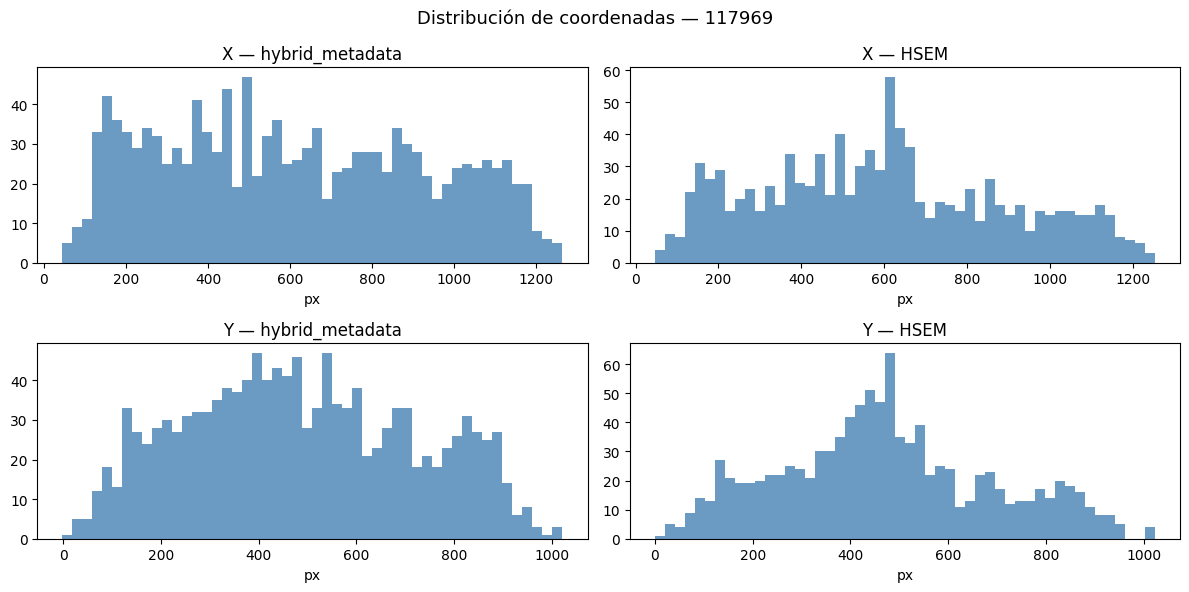

In [7]:
import matplotlib.pyplot as plt

# Comparar distribuciones de X e Y para imágenes en común — primer sujeto como ejemplo
SUBJ_EXAMPLE = common[0]

with open(SCANPATHS_HYB  / f'{SUBJ_EXAMPLE}_scanpaths.json') as f:                sp_hyb  = json.load(f)
with open(SCANPATHS_HSEM / f'{hsem_id_map[SUBJ_EXAMPLE]}_scanpaths.json') as f:   sp_hsem = json.load(f)

common_imgs = set(sp_hyb.keys()) & set(sp_hsem.keys())

X_hyb  = [x for img in common_imgs for x in sp_hyb[img]['X']]
Y_hyb  = [y for img in common_imgs for y in sp_hyb[img]['Y']]
X_hsem = [x for img in common_imgs for x in sp_hsem[img]['X']]
Y_hsem = [y for img in common_imgs for y in sp_hsem[img]['Y']]

print(f'Sujeto: {SUBJ_EXAMPLE} (HSEM: {hsem_id_map[SUBJ_EXAMPLE]})  |  Imágenes en común: {len(common_imgs)}')
print(f'  hybrid_metadata X: min={min(X_hyb):.0f}  max={max(X_hyb):.0f}  media={np.mean(X_hyb):.0f}')
print(f'  HSEM          X: min={min(X_hsem):.0f}  max={max(X_hsem):.0f}  media={np.mean(X_hsem):.0f}')
print(f'  hybrid_metadata Y: min={min(Y_hyb):.0f}  max={max(Y_hyb):.0f}  media={np.mean(Y_hyb):.0f}')
print(f'  HSEM          Y: min={min(Y_hsem):.0f}  max={max(Y_hsem):.0f}  media={np.mean(Y_hsem):.0f}')

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
fig.suptitle(f'Distribución de coordenadas — {SUBJ_EXAMPLE}', fontsize=13)

for ax, vals, title in [
    (axes[0,0], X_hyb,  'X — hybrid_metadata'),
    (axes[0,1], X_hsem, 'X — HSEM'),
    (axes[1,0], Y_hyb,  'Y — hybrid_metadata'),
    (axes[1,1], Y_hsem, 'Y — HSEM'),
]:
    ax.hist(vals, bins=50, color='steelblue', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('px')

plt.tight_layout()
plt.show()

In [8]:
# Para imágenes en común: comparar n_fixaciones trial a trial
SUBJ_EXAMPLE = common[0]

rows_trial = []
for img in sorted(common_imgs):
    n_hyb  = len(sp_hyb[img]['X'])
    n_hsem = len(sp_hsem[img]['X'])
    same_target = sp_hyb[img].get('target_stim') == sp_hsem[img].get('target_stim')
    same_found  = sp_hyb[img].get('target_found') == sp_hsem[img].get('target_found')
    rows_trial.append({
        'imagen'      : img[:45],
        'n_fix_hyb'   : n_hyb,
        'n_fix_hsem'  : n_hsem,
        'diff'        : n_hyb - n_hsem,
        'same_target' : same_target,
        'same_found'  : same_found,
    })

df_trial = pd.DataFrame(rows_trial)
print(f'Discrepancias en target_stim  : {(~df_trial["same_target"]).sum()}')
print(f'Discrepancias en target_found : {(~df_trial["same_found"]).sum()}')
print(f'\nDiferencia en n_fijaciones (hyb - hsem):')
print(f'  Media: {df_trial["diff"].mean():.2f}  |  Std: {df_trial["diff"].std():.2f}')
print(f'  Min: {df_trial["diff"].min()}  |  Max: {df_trial["diff"].max()}')
print()
print(df_trial.to_string(index=False))

Discrepancias en target_stim  : 0
Discrepancias en target_found : 26

Diferencia en n_fijaciones (hyb - hsem):
  Media: 2.48  |  Std: 5.85
  Min: -6  |  Max: 23

                                    imagen  n_fix_hyb  n_fix_hsem  diff  same_target  same_found
cmp_africansavanna_003_wildanimals_003.jpg         20          22    -2         True        True
              cmp_beach_002_person_002.jpg         12           2    10         True        True
                cmp_beach_003_bird_001.jpg         27           4    23         True       False
           cmp_building_003_person_001.jpg          5           5     0         True        True
           cmp_building_006_person_003.jpg         18          18     0         True        True
           cmp_building_007_person_004.jpg         13          14    -1         True        True
              cmp_building_010_cat_002.jpg         13          11     2         True        True
           cmp_building_014_person_007.jpg         22         

---
## 3. Mismo trial, 5 sujetos al azar: HSEM vs hybrid_metadata

Elige una imagen que aparezca en al menos 5 sujetos en ambas fuentes.
Muestra las coordenadas de fijación (X, Y) de cada sujeto lado a lado.

In [9]:
import random

# Cargar todos los scanpaths en memoria
all_sp = {}
for subj in common:
    with open(SCANPATHS_HYB  / f'{subj}_scanpaths.json') as f:
        hyb = json.load(f)
    with open(SCANPATHS_HSEM / f'{hsem_id_map[subj]}_scanpaths.json') as f:
        hsem = json.load(f)
    all_sp[subj] = {'hyb': hyb, 'hsem': hsem}

# Imágenes presentes en al menos 5 sujetos en AMBAS fuentes
from collections import Counter
img_count = Counter()
for subj, sp in all_sp.items():
    for img in set(sp['hyb'].keys()) & set(sp['hsem'].keys()):
        img_count[img] += 1

candidate_imgs = [img for img, cnt in img_count.items() if cnt >= 5]
print(f'Imágenes con ≥5 sujetos en ambas fuentes: {len(candidate_imgs)}')

random.seed(44)
TRIAL_IMG = random.choice(candidate_imgs)
print(f'Imagen seleccionada: {TRIAL_IMG}')

# 5 sujetos al azar que tienen esa imagen en ambas fuentes
subjs_with_img = [s for s in common
                  if TRIAL_IMG in all_sp[s]['hyb'] and TRIAL_IMG in all_sp[s]['hsem']]
sample_subjs   = random.sample(subjs_with_img, min(5, len(subjs_with_img)))
print(f'Sujetos seleccionados: {sample_subjs}')

Imágenes con ≥5 sujetos en ambas fuentes: 102
Imagen seleccionada: cmp_shelves_054_toys_013.jpg
Sujetos seleccionados: ['S115', 'S116', '305138', '419760', 'S103']


In [10]:
print(f'Imagen: {TRIAL_IMG}')
print(f'{"Sujeto":<12}  {"n_fix_hyb":>10}  {"n_fix_hsem":>11}  '
      f'{"diff":>6}  {"target_hyb":<20}  {"target_hsem":<20}')
print('-' * 90)

for subj in sample_subjs:
    hyb  = all_sp[subj]['hyb'][TRIAL_IMG]
    hsem = all_sp[subj]['hsem'][TRIAL_IMG]
    n_h  = len(hyb['X'])
    n_s  = len(hsem['X'])
    print(f'{subj:<12}  {n_h:>10}  {n_s:>11}  {n_h-n_s:>+6}  '
          f'{str(hyb.get("target_stim","")):<20}  {str(hsem.get("target_stim","")):<20}')

print()

# Detalle de coordenadas por sujeto
for subj in sample_subjs:
    hyb  = all_sp[subj]['hyb'][TRIAL_IMG]
    hsem = all_sp[subj]['hsem'][TRIAL_IMG]
    print(f'── {subj} ───────────────────────────────────────────────────')
    print(f'  hybrid  ({len(hyb["X"]):2d} fix)  X: {[round(x,1) for x in hyb["X"]]}')
    print(f'  hybrid  ({len(hyb["Y"]):2d} fix)  Y: {[round(y,1) for y in hyb["Y"]]}')
    print(f'  HSEM    ({len(hsem["X"]):2d} fix)  X: {[round(x,1) for x in hsem["X"]]}')
    print(f'  HSEM    ({len(hsem["Y"]):2d} fix)  Y: {[round(y,1) for y in hsem["Y"]]}')
    print()

Imagen: cmp_shelves_054_toys_013.jpg
Sujeto         n_fix_hyb   n_fix_hsem    diff  target_hyb            target_hsem         
------------------------------------------------------------------------------------------
S115                   4            5      -1  truck319.png          truck319.png        
S116                   8            7      +1  truck319.png          truck319.png        
305138                 9            9      +0  truck319.png          truck319.png        
419760                 8            9      -1  truck319.png          truck319.png        
S103                   1            2      -1  truck319.png          truck319.png        

── S115 ───────────────────────────────────────────────────
  hybrid  ( 4 fix)  X: [666.7, 555.5, 1015.3, 1076.3]
  hybrid  ( 4 fix)  Y: [551.5, 619.1, 414.7, 324.8]
  HSEM    ( 5 fix)  X: [521.8, 660.6, 557.5, 1013.9, 1071.9]
  HSEM    ( 5 fix)  Y: [477.7, 550.9, 617.5, 416.2, 326.6]

── S116 ────────────────────────────────────

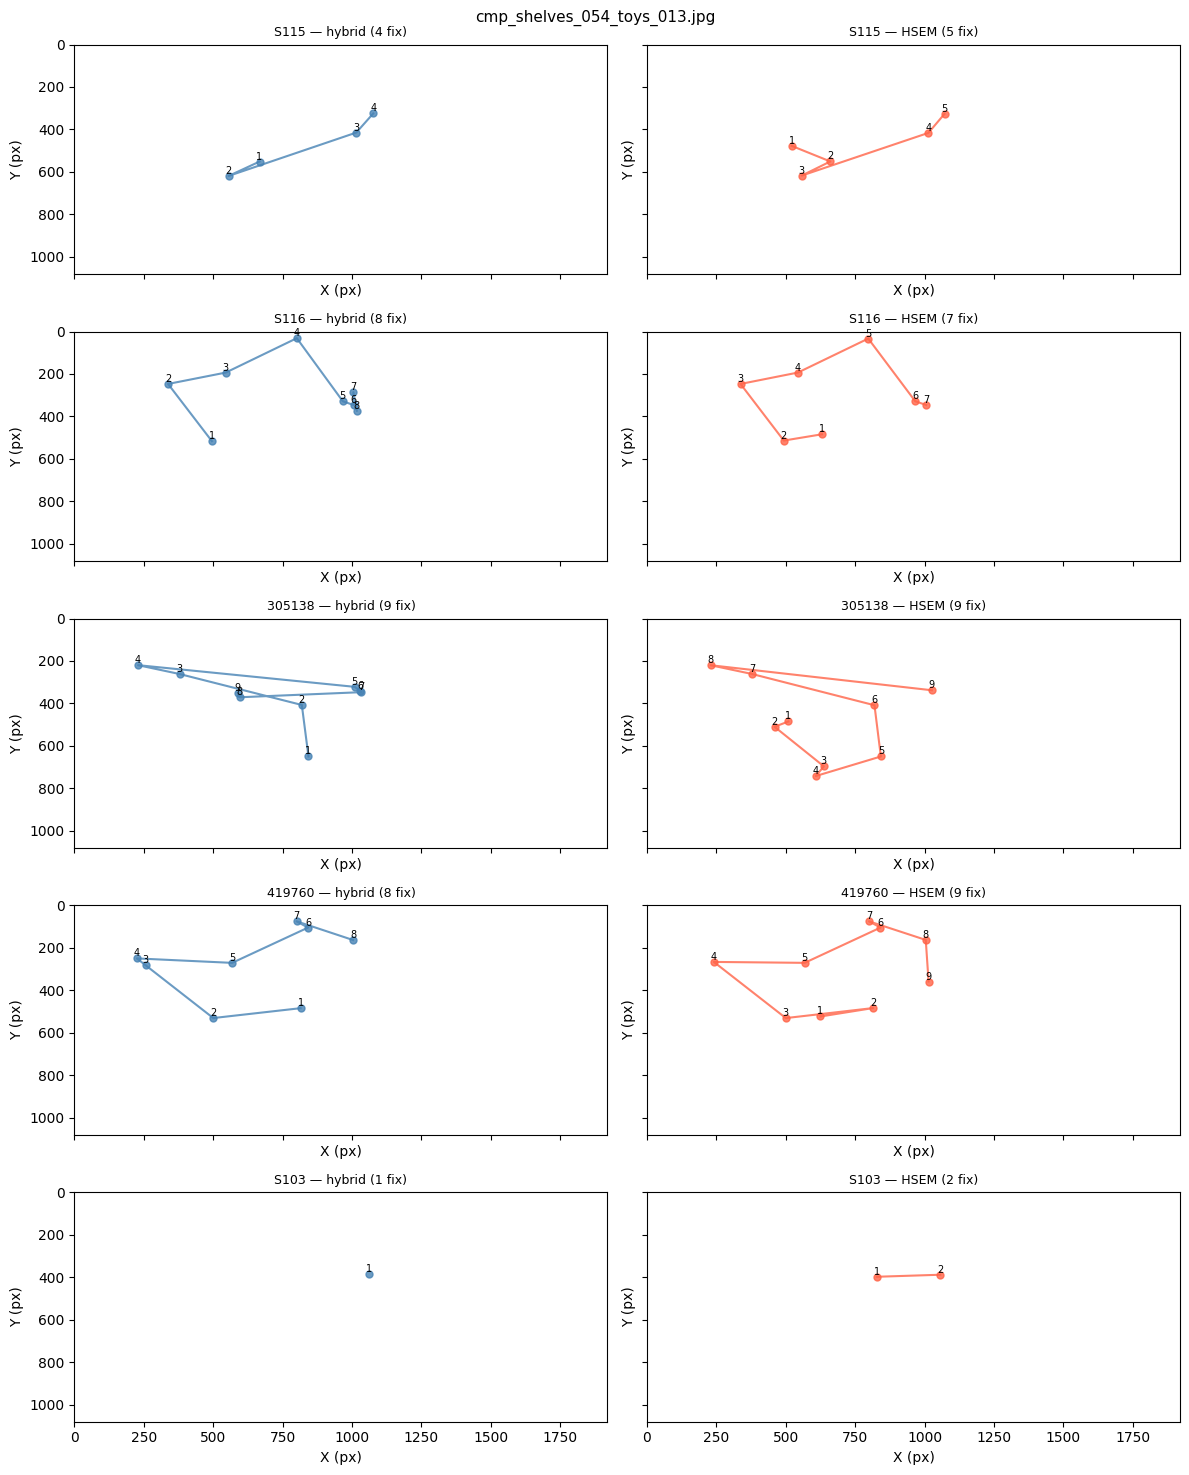

In [11]:
fig, axes = plt.subplots(len(sample_subjs), 2, figsize=(12, 3 * len(sample_subjs)),
                         sharex=True, sharey=True)
fig.suptitle(f'{TRIAL_IMG}', fontsize=11)

for row, subj in enumerate(sample_subjs):
    hyb  = all_sp[subj]['hyb'][TRIAL_IMG]
    hsem = all_sp[subj]['hsem'][TRIAL_IMG]

    for ax, sp, label, color in [
        (axes[row, 0], hyb,  'hybrid', 'steelblue'),
        (axes[row, 1], hsem, 'HSEM',   'tomato'),
    ]:
        xs = sp['X']
        ys = sp['Y']
        ax.plot(xs, ys, '-o', color=color, markersize=5, alpha=0.8)
        for i, (x, y) in enumerate(zip(xs, ys)):
            ax.annotate(str(i+1), (x, y), fontsize=7, ha='center', va='bottom')
        ax.set_title(f'{subj} — {label} ({len(xs)} fix)', fontsize=9)
        ax.set_xlim(0, 1920)
        ax.set_ylim(1080, 0)   # origen arriba-izquierda
        ax.set_xlabel('X (px)')
        ax.set_ylabel('Y (px)')

plt.tight_layout()
plt.show()

---
## 3.5 Comparación de fijaciones para sujetos e imágenes específicos

Compara las coordenadas de fijación (X, Y) de **sujetos e imágenes a elección** entre `hybrid_metadata` y `HSEM`.
Editá las variables `SUBJS_SEL` e `IMGS_SEL` para elegir qué comparar.

Sujeto        Imagen                                               n_hyb   n_hsem   diff
-------------------------------------------------------------------------------------
677251        cmp_shelves_073_toys_032.jpg                             7        2     +5
373490        cmp_shelves_073_toys_032.jpg                            26       13    +13
S108          cmp_shelves_073_toys_032.jpg                            24        3    +21
S101          cmp_shelves_073_toys_032.jpg                            21       10    +11
286470        cmp_shelves_073_toys_032.jpg                             4        5     -1

── 677251  |  cmp_shelves_073_toys_032.jpg
   hybrid  ( 7 fix)  X: [431.9, 394.1, 501.4, 420.8, 400.2, 913.8, 953.9]
   hybrid  ( 7 fix)  Y: [584.0, 220.1, 185.5, 658.3, 613.6, 915.1, 858.0]
   HSEM    ( 2 fix)  X: [603.3, 431.8]
   HSEM    ( 2 fix)  Y: [525.0, 584.2]

── 373490  |  cmp_shelves_073_toys_032.jpg
   hybrid  (26 fix)  X: [479.6, 500.9, 579.3, 318.5, 942.1, 900.1,

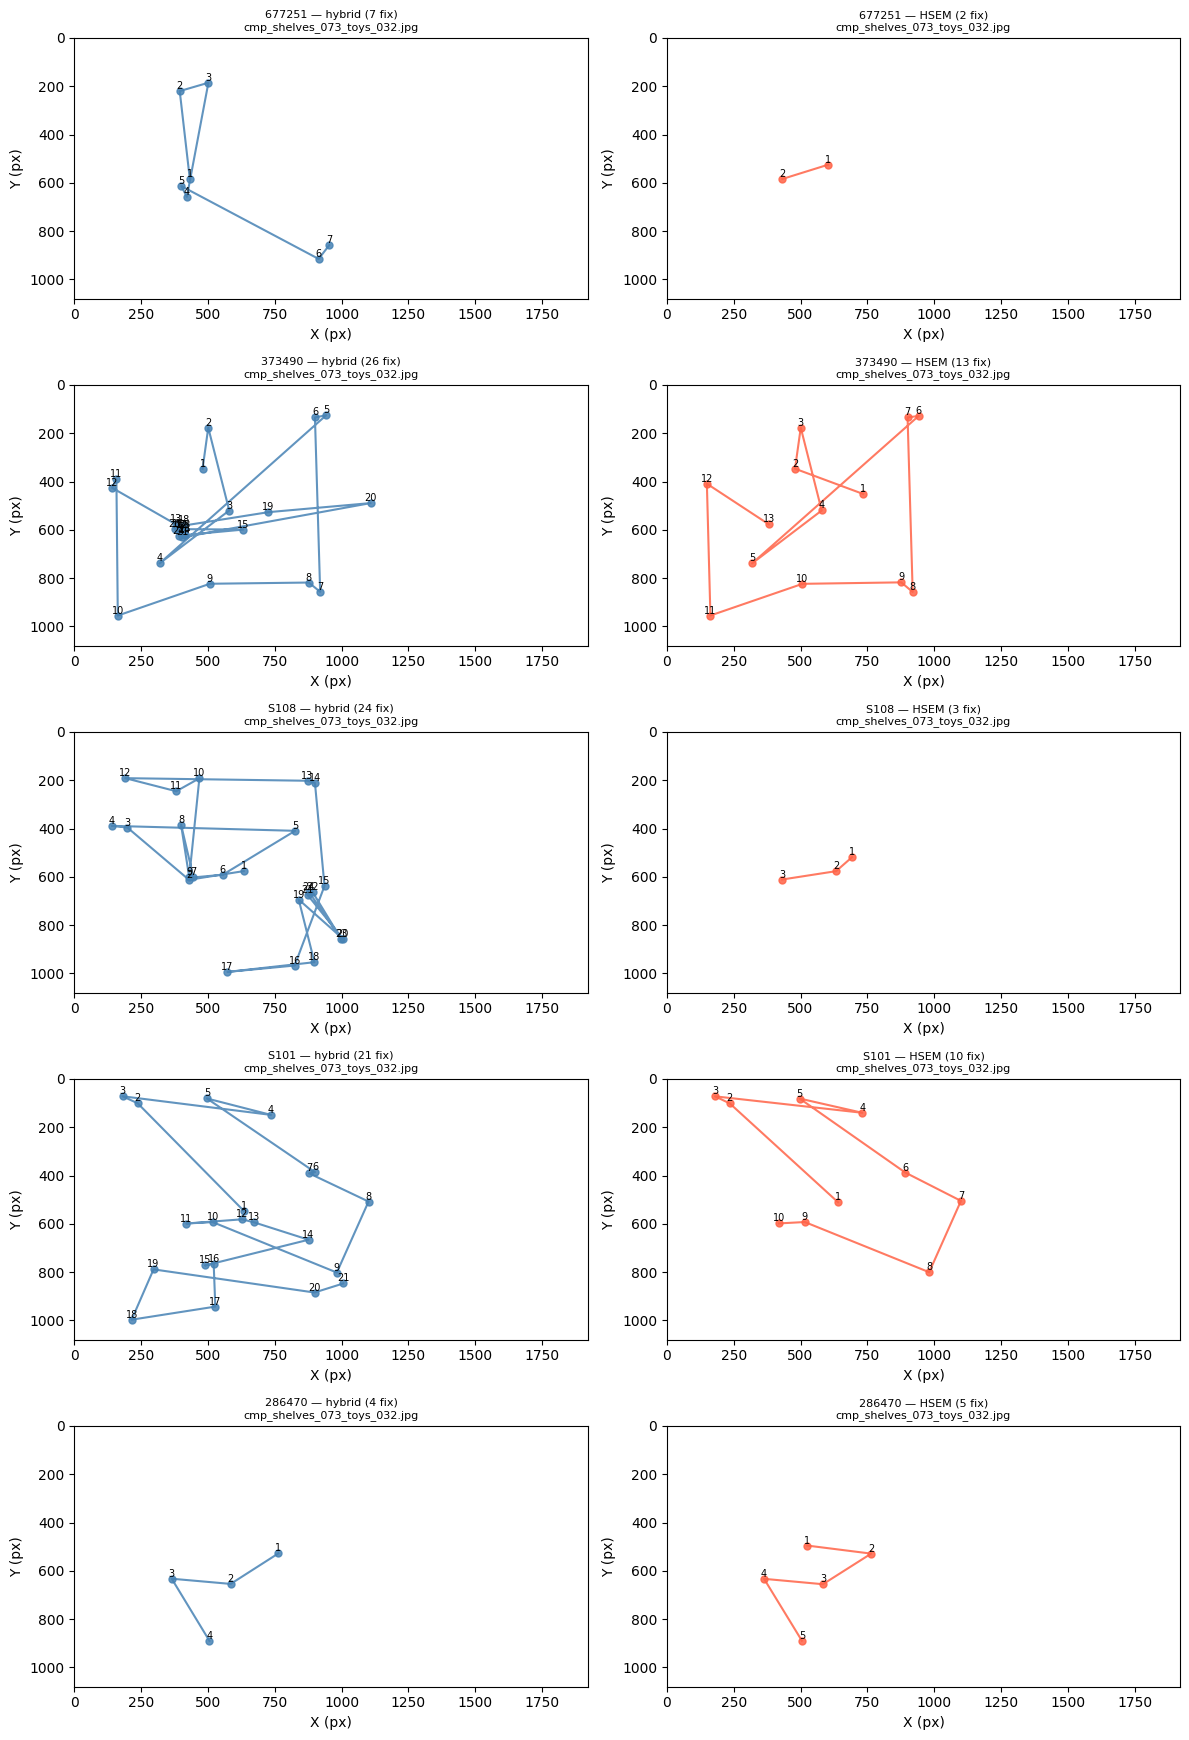

In [12]:
# ── Configurar aquí ─────────────────────────────────────────────────────────
SUBJS_SEL = ['677251', '373490', 'S108', 'S101', '286470']                          # sujetos a comparar
IMGS_SEL  = [                                          # imágenes a comparar
    'cmp_shelves_073_toys_032.jpg',
]
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt

# Validar que los sujetos y las imágenes existen en ambas fuentes
valid_pairs = []
for subj in SUBJS_SEL:
    if subj not in all_sp:
        print(f'[SKIP] sujeto "{subj}" no encontrado en common')
        continue
    for img in IMGS_SEL:
        hyb  = all_sp[subj]['hyb'].get(img)
        hsem = all_sp[subj]['hsem'].get(img)
        if hyb is None or hsem is None:
            print(f'[SKIP] {subj} / {img} — no disponible en {"hybrid" if hyb is None else "HSEM"}')
            continue
        valid_pairs.append((subj, img, hyb, hsem))

if not valid_pairs:
    print('No hay pares válidos para mostrar.')
else:
    # ── Tabla resumen ────────────────────────────────────────────────────────
    print(f'{"Sujeto":<12}  {"Imagen":<50}  {"n_hyb":>6}  {"n_hsem":>7}  {"diff":>5}')
    print('-' * 85)
    for subj, img, hyb, hsem in valid_pairs:
        n_h, n_s = len(hyb['X']), len(hsem['X'])
        print(f'{subj:<12}  {img:<50}  {n_h:>6}  {n_s:>7}  {n_h-n_s:>+5}')

    print()

    # ── Coordenadas detalladas ────────────────────────────────────────────────
    for subj, img, hyb, hsem in valid_pairs:
        print(f'── {subj}  |  {img}')
        print(f'   hybrid  ({len(hyb["X"]):2d} fix)  X: {[round(x,1) for x in hyb["X"]]}')
        print(f'   hybrid  ({len(hyb["Y"]):2d} fix)  Y: {[round(y,1) for y in hyb["Y"]]}')
        print(f'   HSEM    ({len(hsem["X"]):2d} fix)  X: {[round(x,1) for x in hsem["X"]]}')
        print(f'   HSEM    ({len(hsem["Y"]):2d} fix)  Y: {[round(y,1) for y in hsem["Y"]]}')
        print()

    # ── Plots: scanpath hybrid vs HSEM ───────────────────────────────────────
    n_pairs = len(valid_pairs)
    fig, axes = plt.subplots(n_pairs, 2, figsize=(12, 3.5 * n_pairs),
                             sharex=False, sharey=False)
    if n_pairs == 1:
        axes = [axes]   # uniformizar forma para iterar

    for row, (subj, img, hyb, hsem) in enumerate(valid_pairs):
        for ax, sp, label, color in [
            (axes[row][0], hyb,  'hybrid', 'steelblue'),
            (axes[row][1], hsem, 'HSEM',   'tomato'),
        ]:
            xs, ys = sp['X'], sp['Y']
            ax.plot(xs, ys, '-o', color=color, markersize=5, alpha=0.85)
            for i, (x, y) in enumerate(zip(xs, ys)):
                ax.annotate(str(i + 1), (x, y), fontsize=7,
                            ha='center', va='bottom', color='black')
            ax.set_title(f'{subj} — {label} ({len(xs)} fix)\n{img[:45]}', fontsize=8)
            ax.set_xlim(0, 1920)
            ax.set_ylim(1080, 0)
            ax.set_xlabel('X (px)')
            ax.set_ylabel('Y (px)')

    plt.tight_layout()
    plt.show()

---
## 3.6 Casos con mayor discrepancia hybrid vs HSEM

Deep-dive en los 6 pares (sujeto, imagen) con mayor diferencia en n_fijaciones.
Incluye el caso S108 analizado previamente y los 5 del top de discrepancias globales.

| Sujeto | Imagen | n_hyb | n_hsem | diff |
|--------|--------|------:|-------:|-----:|
| S108 | cmp_shelves_073_toys_032.jpg | 24 | 3 | +21 |
| 601753 | cmp_yard_007_motorcycle_001.jpg | 38 | 2 | +36 |
| S101 | cmp_jungle_007_bird_007.jpg | 38 | 2 | +36 |
| S119 | cmp_field_008_farmanimals_008.jpg | 40 | 4 | +36 |
| 601753 | cmp_beach_002_person_002.jpg | 38 | 3 | +35 |
| S102 | cmp_desks_002_backpacks_001.jpg | 41 | 6 | +35 |


═════════════════════════════════════════════════════════════════
  S108  |  cmp_shelves_073_toys_032.jpg
═════════════════════════════════════════════════════════════════
  trial=76  MSS=2  target=airplane1306.png  cat=T  found=True
  memory_set: ['bus543.png', 'airplane1306.png']

── Fijaciones full_metadata (24) ──
     latency        img_x       img_y  duration ontarget ondistractor                stm inrange  bad  rank
0   598619.0   633.562134  576.377625        83    False         True  motorcycle193.png    True    0   1.0
1   598725.0   428.698975  612.360046        92     True        False   airplane1306.png    True    0   2.0
2   598844.0   198.284241  395.986084        57      NaN          NaN                NaN    True    0   3.0
3   598913.0   140.055054  388.999023        75    False         True   airplane1071.png    True    0   4.0
4   599073.0   825.819336  409.508118        67      NaN          NaN                NaN    True    0   5.0
5   599176.0   555.134644  591.

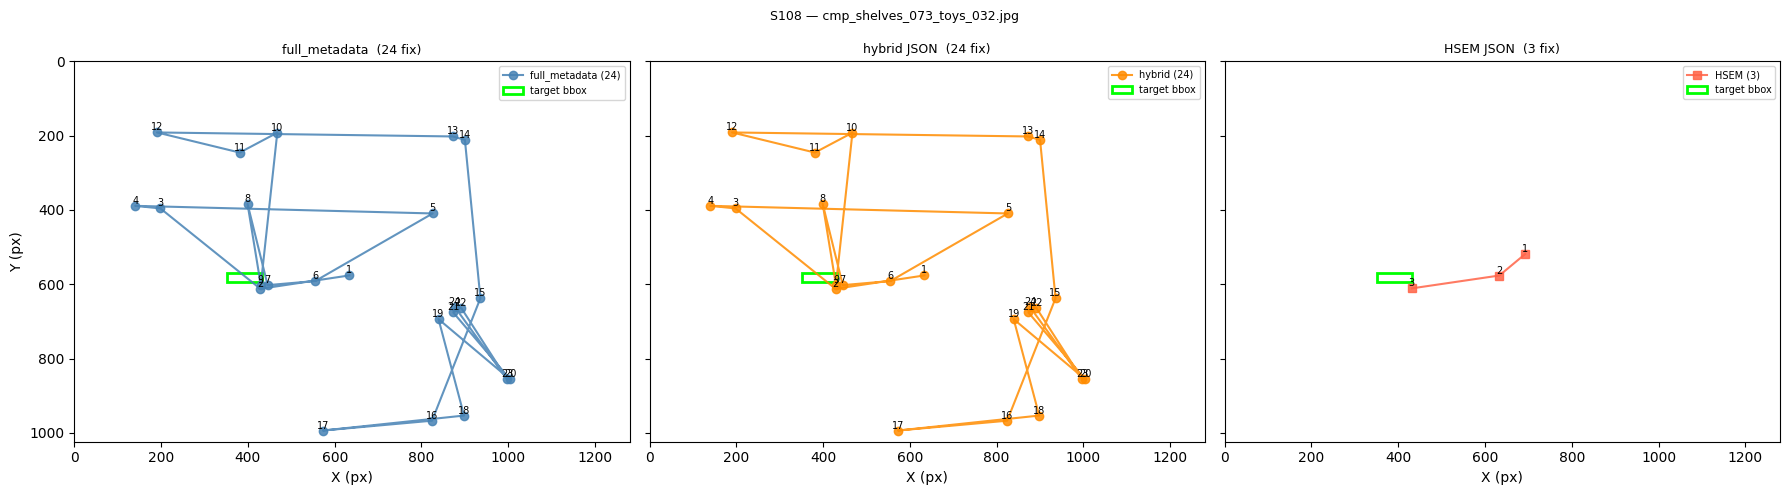


── Resumen ──
  full_metadata : 24  |  hybrid JSON : 24  |  HSEM : 3
  diff (hybrid − HSEM) : +21
  bad≠0 → 0  |  inrange=False → -48
  ontarget=True → 2  |  ondistractor=True → 14

═════════════════════════════════════════════════════════════════
  601753  |  cmp_yard_007_motorcycle_001.jpg
═════════════════════════════════════════════════════════════════
  trial=204  MSS=4  target=motorcycle807.png  cat=T  found=False
  memory_set: ['motorcycle707.png', 'motorcycle779.png', 'motorcycle793.png', 'motorcycle807.png']

── Fijaciones full_metadata (38) ──
      latency        img_x       img_y  duration ontarget ondistractor                stm inrange  bad  rank
0   1388601.0   473.456604  365.482544        45      NaN          NaN                NaN    True    0   1.0
1   1388668.0   431.792053  352.003082       175     True        False  motorcycle807.png    True    0   2.0
2   1388867.0  1038.191528  440.818268        55      NaN          NaN                NaN    True    0   3.0
3  

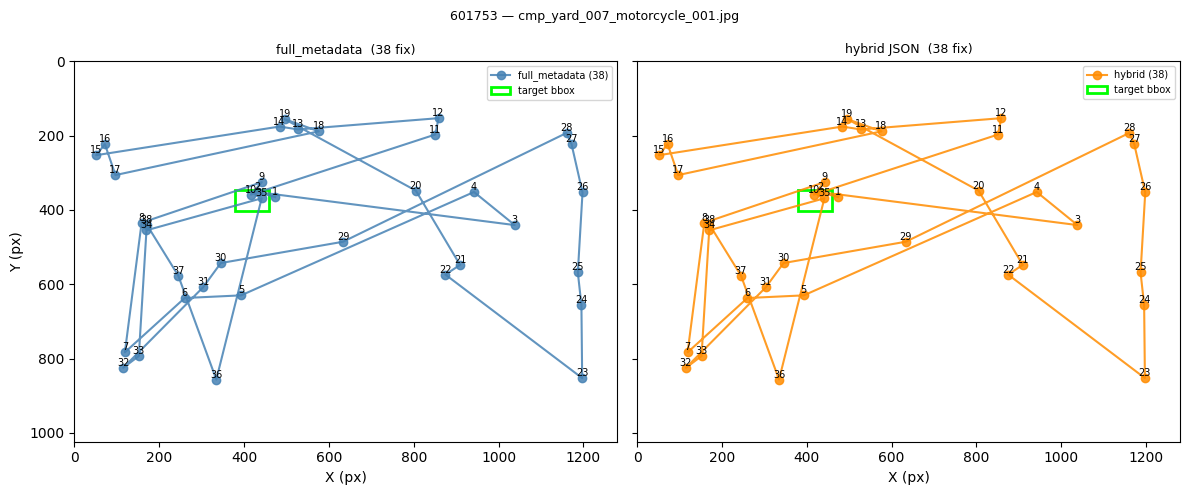


── Resumen ──
  full_metadata : 38  |  hybrid JSON : 38  |  HSEM : N/A
  bad≠0 → 0  |  inrange=False → -76
  ontarget=True → 3  |  ondistractor=True → 17

═════════════════════════════════════════════════════════════════
  S101  |  cmp_jungle_007_bird_007.jpg
═════════════════════════════════════════════════════════════════
  trial=48  MSS=1  target=bird332.png  cat=T  found=False
  memory_set: ['bird332.png']

── Fijaciones full_metadata (38) ──
     latency        img_x        img_y  duration ontarget ondistractor          stm inrange  bad  rank
0   384395.0   911.094604   334.590607        36      NaN          NaN          NaN    True    0   1.0
1   384449.0   959.694092   296.273651        82     True        False  bird332.png    True    0   2.0
2   384540.0   971.861084   284.750793        64     True        False  bird332.png    True    0   3.0
3   384636.0  1138.405762   255.968781       134    False         True  bird203.png    True    0   4.0
4   384805.0  1104.190552   497.4

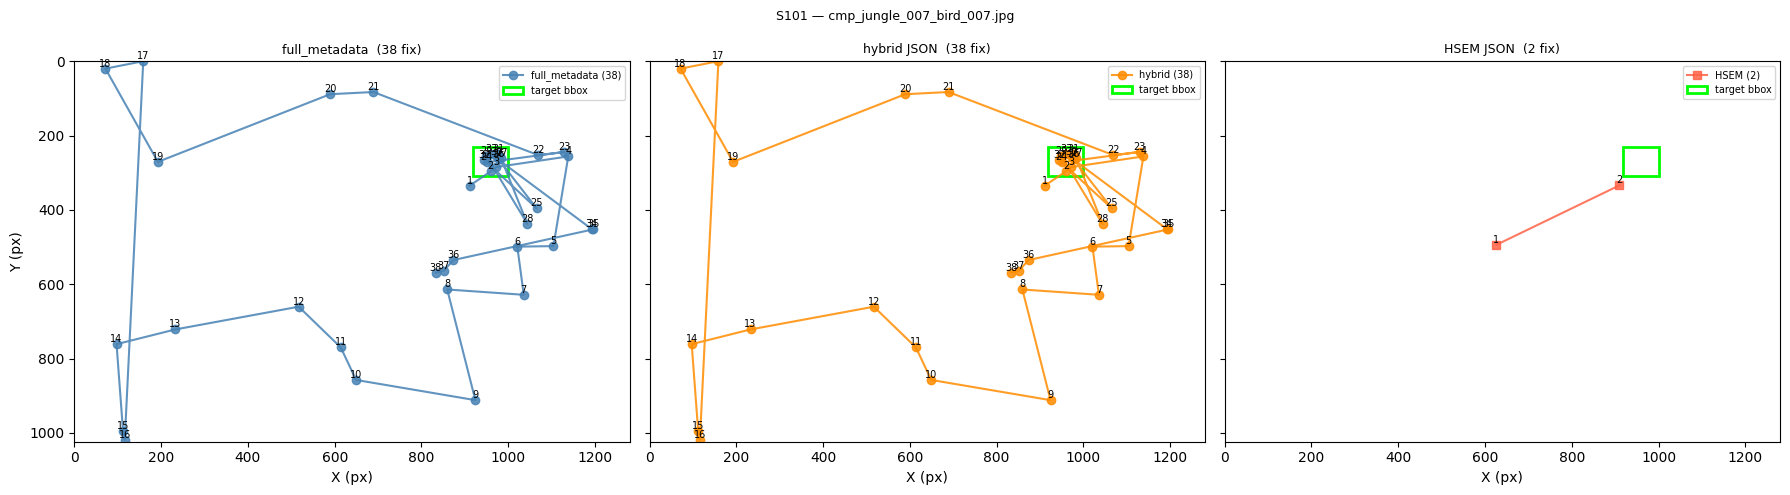


── Resumen ──
  full_metadata : 38  |  hybrid JSON : 38  |  HSEM : 2
  diff (hybrid − HSEM) : +36
  bad≠0 → 0  |  inrange=False → -76
  ontarget=True → 10  |  ondistractor=True → 9

═════════════════════════════════════════════════════════════════
  S119  |  cmp_field_008_farmanimals_008.jpg
═════════════════════════════════════════════════════════════════
  trial=194  MSS=2  target=sheep580.png  cat=T  found=False
  memory_set: ['sheep1060.png', 'sheep580.png']

── Fijaciones full_metadata (40) ──
      latency        img_x       img_y  duration ontarget ondistractor            stm inrange  bad  rank
0   1701024.0   796.590088  547.245850        78      NaN          NaN            NaN    True    0   1.0
1   1701136.0  1012.599976  295.207642        83      NaN          NaN            NaN    True    0   2.0
2   1701242.0  1160.106201  283.350983       137      NaN          NaN            NaN    True    0   3.0
3   1701425.0   406.106934  442.222198        68      NaN          NaN     

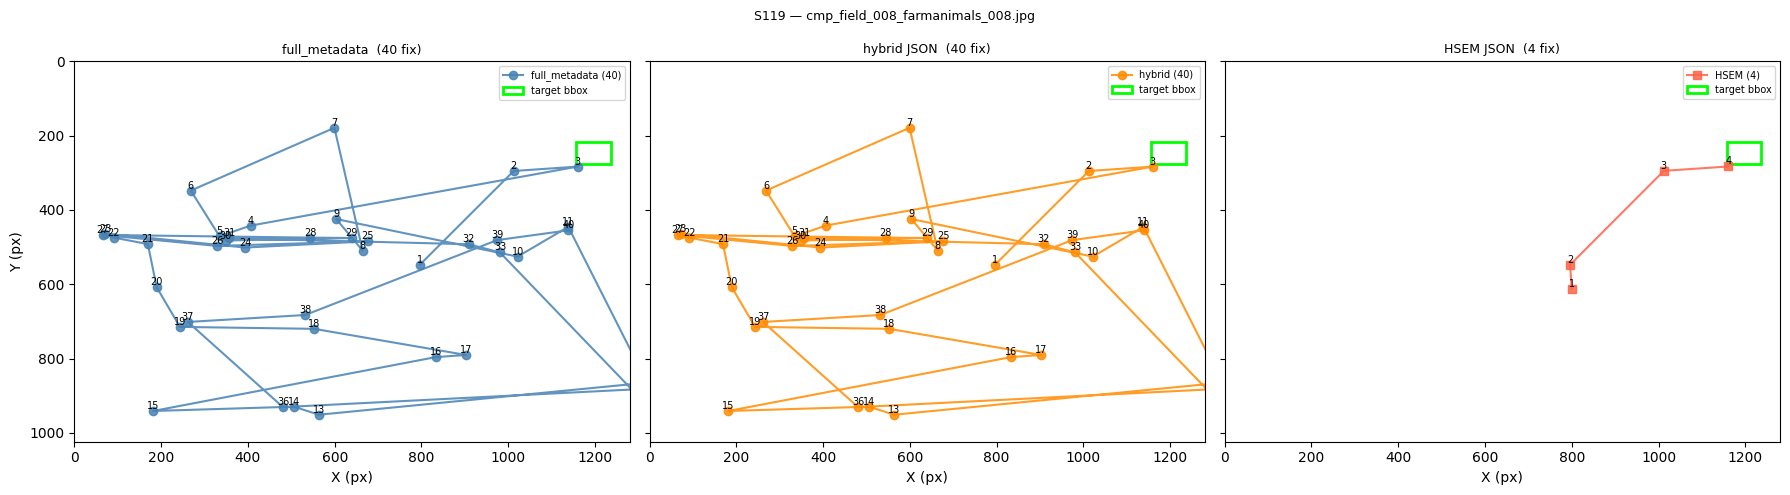


── Resumen ──
  full_metadata : 40  |  hybrid JSON : 40  |  HSEM : 4
  diff (hybrid − HSEM) : +36
  bad≠0 → 0  |  inrange=False → -80
  ontarget=True → 0  |  ondistractor=True → 12

═════════════════════════════════════════════════════════════════
  601753  |  cmp_beach_002_person_002.jpg
═════════════════════════════════════════════════════════════════
  trial=119  MSS=2  target=person17425.png  cat=T  found=False
  memory_set: ['person16329.png', 'person17425.png']

── Fijaciones full_metadata (38) ──
     latency        img_x       img_y  duration ontarget ondistractor              stm inrange  bad  rank
0   836521.0   624.653198  444.478424        71      NaN          NaN              NaN    True    0   1.0
1   836596.0   627.980652  440.211945        93      NaN          NaN              NaN    True    0   2.0
2   836700.0   627.695557  469.912933        97      NaN          NaN              NaN    True    0   3.0
3   836820.0   387.045898  359.311493        76     True        Fa

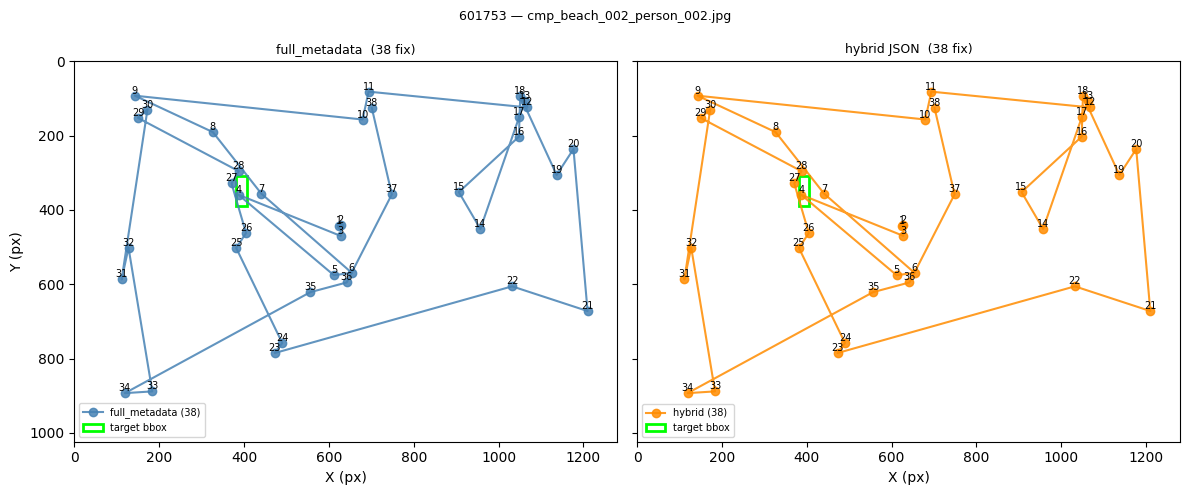


── Resumen ──
  full_metadata : 38  |  hybrid JSON : 38  |  HSEM : N/A
  bad≠0 → 0  |  inrange=False → -76
  ontarget=True → 3  |  ondistractor=True → 14

═════════════════════════════════════════════════════════════════
  S102  |  cmp_desks_002_backpacks_001.jpg
═════════════════════════════════════════════════════════════════
  trial=63  MSS=4  target=backpack599.png  cat=T  found=False
  memory_set: ['backpack615.png', 'backpack616.png', 'backpack1073.png', 'backpack599.png']

── Fijaciones full_metadata (41) ──
     latency        img_x       img_y  duration ontarget ondistractor              stm inrange  bad  rank
0   555634.0   532.319092  481.888824        97      NaN          NaN              NaN    True    0   1.0
1   555750.0   326.952209  525.100220       109    False         True  backpack566.png    True    0   2.0
2   555881.0   411.547974  317.103058        73    False         True  backpack366.png    True    0   3.0
3   555975.0   176.376556  539.936646       112    Fal

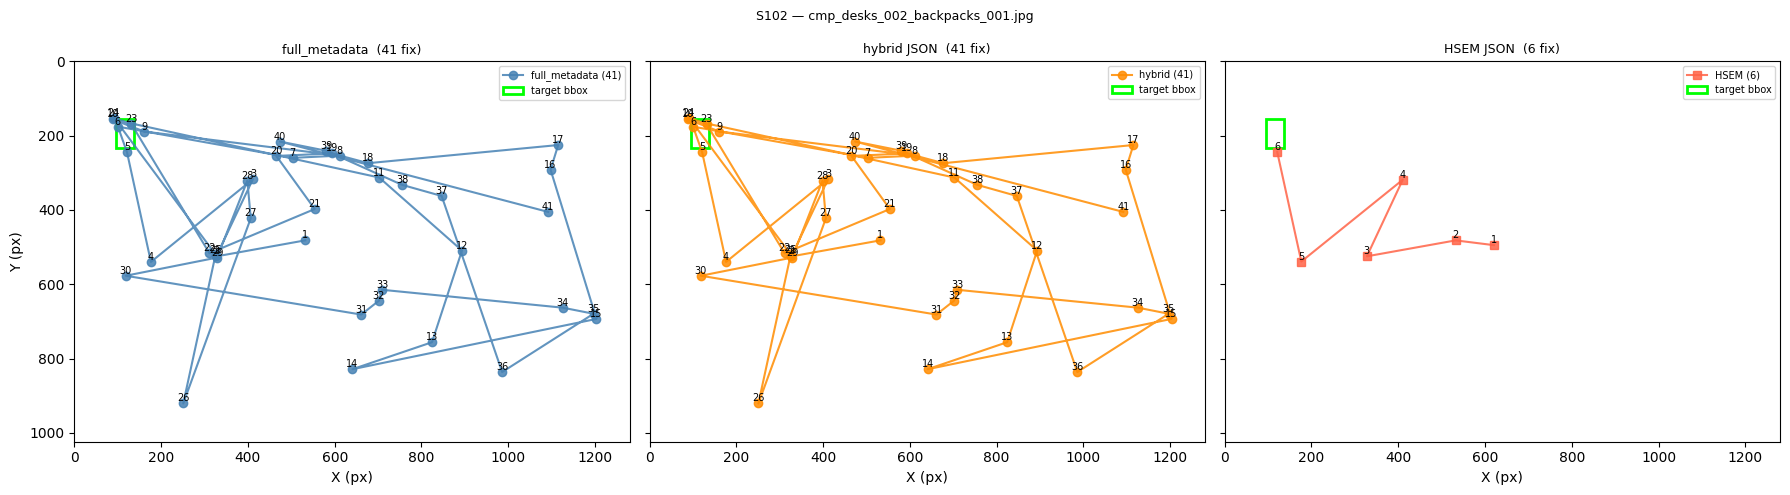


── Resumen ──
  full_metadata : 41  |  hybrid JSON : 41  |  HSEM : 6
  diff (hybrid − HSEM) : +35
  bad≠0 → 0  |  inrange=False → -82
  ontarget=True → 5  |  ondistractor=True → 21


In [13]:
import glob, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ── Casos a analizar ─────────────────────────────────────────────────────────
CASOS = [
    ('S108',   'cmp_shelves_073_toys_032.jpg'),
    ('601753', 'cmp_yard_007_motorcycle_001.jpg'),
    ('S101',   'cmp_jungle_007_bird_007.jpg'),
    ('S119',   'cmp_field_008_farmanimals_008.jpg'),
    ('601753', 'cmp_beach_002_person_002.jpg'),
    ('S102',   'cmp_desks_002_backpacks_001.jpg'),
]

IMG_W, IMG_H = 1280, 1024
X_OFF = (1920 - IMG_W) / 2   # 320 px
Y_OFF = (1080 - IMG_H) / 2   # 28 px

SCANPATHS_HYB  = '../hybrid_metadata/human_scanpaths'
SCANPATHS_HSEM = '../Datasets/HSEM/human_scanpaths'

def find_bh(subj):
    """Busca el CSV de comportamiento en UBA o UON."""
    paths = (glob.glob(f'../hybrid_metadata/UBA/{subj}/*.csv') +
             glob.glob(f'../hybrid_metadata/UON/{subj}_*.csv'))
    return paths[0] if paths else None

def get_trial_info(bh_path, img):
    bh     = pd.read_csv(bh_path, encoding='utf-8-sig')
    rows   = bh[bh['searchimage'] == img]
    if rows.empty:
        return None, None, None
    blk    = rows.index[0] // 6
    row0   = bh.iloc[blk * 6]
    row5   = bh.iloc[blk * 6 + 5]
    trial  = int(blk) + 1
    info   = {
        'trial'        : trial,
        'mss'          : int(row0['Nstim']) if pd.notna(row0['Nstim']) else None,
        'target_stim'  : row0['st5'].split('/')[-1],
        'target_cat'   : row0['st5_cat'],
        'memory_set'   : [row0[c].split('/')[-1] for c in ['st1','st2','st3','st4','st5']
                          if 'blank' not in str(row0[c])],
        'target_found' : row5['key_resp.corr'] == 1.0,
    }
    return trial, info, bh

def add_bbox(ax, bbox):
    rect = patches.Rectangle(
        (bbox[1], bbox[0]), bbox[3] - bbox[1], bbox[2] - bbox[0],
        linewidth=2, edgecolor='lime', facecolor='none', label='target bbox'
    )
    ax.add_patch(rect)

def plot_sp(ax, xs, ys, color, label, marker='o'):
    ax.plot(xs, ys, f'-{marker}', color=color, markersize=6, alpha=0.85, label=label)
    for i, (x, y) in enumerate(zip(xs, ys)):
        ax.annotate(str(i + 1), (x, y), fontsize=7, ha='center', va='bottom')

# ── Loop sobre casos ─────────────────────────────────────────────────────────
for subj, img in CASOS:
    print('\n' + '═' * 65)
    print(f'  {subj}  |  {img}')
    print('═' * 65)

    # 1. Trial info
    bh_path = find_bh(subj)
    if bh_path:
        trial_num, info, _ = get_trial_info(bh_path, img)
        if info:
            print(f'  trial={info["trial"]}  MSS={info["mss"]}  target={info["target_stim"]}'
                  f'  cat={info["target_cat"]}  found={info["target_found"]}')
            print(f'  memory_set: {info["memory_set"]}')
    else:
        trial_num = None
        print('  [bh no encontrado]')

    # 2. Fijaciones desde full_metadata
    df  = pd.read_csv(f'../hybrid_metadata/output/{subj}_full_metadata.csv')
    fix = df[
        (df['trial'] == trial_num) &
        (df['type']  == 'fixation') &
        (df['phase'] == 'vs')
    ].copy().reset_index(drop=True) if trial_num else pd.DataFrame()

    fix['img_x'] = fix['fix_avgpos_x'] - X_OFF
    fix['img_y'] = fix['fix_avgpos_y'] - Y_OFF

    print(f'\n── Fijaciones full_metadata ({len(fix)}) ──')
    if not fix.empty:
        cols = ['latency','img_x','img_y','duration','ontarget','ondistractor','stm','inrange','bad','rank']
        print(fix[cols].to_string(index=True))

    # 3. JSONs
    with open(f'{SCANPATHS_HYB}/{subj}_scanpaths.json') as f:
        sp_hyb = json.load(f).get(img)

    hsem_path = f'{SCANPATHS_HSEM}/{subj}_scanpaths.json'
    try:
        with open(hsem_path) as f:
            sp_hsem = json.load(f).get(img)
    except FileNotFoundError:
        sp_hsem = None

    print(f'\n── JSON hybrid  ({len(sp_hyb["X"]) if sp_hyb else "N/A"} fix) ──')
    if sp_hyb:
        print(f'  target={sp_hyb["target_stim"]}  found={sp_hyb["target_found"]}')
        print(f'  bbox  : {sp_hyb["target_bbox"]}')
        print(f'  X: {[round(x,1) for x in sp_hyb["X"]]}')
        print(f'  Y: {[round(y,1) for y in sp_hyb["Y"]]}')

    print(f'\n── JSON HSEM    ({len(sp_hsem["X"]) if sp_hsem else "N/A"} fix) ──')
    if sp_hsem:
        print(f'  target={sp_hsem["target_stim"]}  found={sp_hsem["target_found"]}')
        print(f'  X: {[round(x,1) for x in sp_hsem["X"]]}')
        print(f'  Y: {[round(y,1) for y in sp_hsem["Y"]]}')
    else:
        print('  [HSEM no disponible para este sujeto]')

    # 4. Plot
    n_panels = 3 if sp_hsem else 2
    fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5),
                             sharex=True, sharey=True)
    fig.suptitle(f'{subj} — {img}', fontsize=9)

    bbox = sp_hyb['target_bbox'] if sp_hyb else None

    # Panel: full_metadata
    ax = axes[0]
    if not fix.empty:
        plot_sp(ax, fix['img_x'], fix['img_y'], 'steelblue', f'full_metadata ({len(fix)})')
    if bbox:
        add_bbox(ax, bbox)
    ax.set_title(f'full_metadata  ({len(fix)} fix)', fontsize=9)
    ax.set_xlim(0, IMG_W); ax.set_ylim(IMG_H, 0)
    ax.set_xlabel('X (px)'); ax.set_ylabel('Y (px)')
    ax.legend(fontsize=7)

    # Panel: hybrid JSON
    ax = axes[1]
    if sp_hyb:
        plot_sp(ax, sp_hyb['X'], sp_hyb['Y'], 'darkorange', f'hybrid ({len(sp_hyb["X"])})')
        if bbox:
            add_bbox(ax, bbox)
    ax.set_title(f'hybrid JSON  ({len(sp_hyb["X"]) if sp_hyb else 0} fix)', fontsize=9)
    ax.set_xlim(0, IMG_W); ax.set_ylim(IMG_H, 0)
    ax.set_xlabel('X (px)')
    ax.legend(fontsize=7)

    # Panel: HSEM (si existe)
    if sp_hsem:
        ax = axes[2]
        plot_sp(ax, sp_hsem['X'], sp_hsem['Y'], 'tomato', f'HSEM ({len(sp_hsem["X"])})', marker='s')
        if bbox:
            add_bbox(ax, bbox)
        ax.set_title(f'HSEM JSON  ({len(sp_hsem["X"])} fix)', fontsize=9)
        ax.set_xlim(0, IMG_W); ax.set_ylim(IMG_H, 0)
        ax.set_xlabel('X (px)')
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

    # 5. Resumen
    n_hyb  = len(sp_hyb['X'])  if sp_hyb  else 0
    n_hsem = len(sp_hsem['X']) if sp_hsem else None
    n_bad  = int((fix['bad'] != 0).sum())  if not fix.empty else '—'
    n_out  = int((~fix['inrange']).sum())  if not fix.empty else '—'
    print(f'\n── Resumen ──')
    print(f'  full_metadata : {len(fix):2d}  |  hybrid JSON : {n_hyb:2d}'
          f'  |  HSEM : {n_hsem if n_hsem is not None else "N/A"}')
    if n_hsem is not None:
        print(f'  diff (hybrid − HSEM) : {n_hyb - n_hsem:+d}')
    if not fix.empty:
        print(f'  bad≠0 → {n_bad}  |  inrange=False → {n_out}')
        print(f'  ontarget=True → {int(fix["ontarget"].sum())}  |  '
              f'ondistractor=True → {int(fix["ondistractor"].sum())}')

---
## 4. Cantidad de fijaciones por trial — todos los sujetos

Para cada par (sujeto, imagen) en común, compara `n_fixaciones` entre hybrid_metadata y HSEM.
Responde: ¿con qué frecuencia coinciden?

In [14]:
rows_all = []
for subj in common:
    sp_h = all_sp[subj]['hyb']
    sp_s = all_sp[subj]['hsem']
    for img in sorted(set(sp_h.keys()) & set(sp_s.keys())):
        n_h = len(sp_h[img]['X'])
        n_s = len(sp_s[img]['X'])
        rows_all.append({
            'subject'   : subj,
            'image'     : img,
            'n_hyb'     : n_h,
            'n_hsem'    : n_s,
            'diff'      : n_h - n_s,
            'abs_diff'  : abs(n_h - n_s),
            'coincide'  : n_h == n_s,
        })

df_all = pd.DataFrame(rows_all)

total      = len(df_all)
coinciden  = df_all['coincide'].sum()
print(f'Pares (sujeto, imagen) analizados : {total}')
print(f'Con mismo n_fijaciones            : {coinciden}  ({100*coinciden/total:.1f}%)')
print(f'Con distinto n_fijaciones         : {total - coinciden}  ({100*(total-coinciden)/total:.1f}%)')
print()
print('Distribución de diferencias (hyb - hsem):')
print(df_all['diff'].describe().round(2).to_string())
print()

# Casos extremos
top_diff = df_all.nlargest(5, 'abs_diff')[['subject','image','n_hyb','n_hsem','diff']]
print('Top 5 mayores diferencias absolutas:')
print(top_diff.to_string(index=False))

Pares (sujeto, imagen) analizados : 3915
Con mismo n_fijaciones            : 601  (15.4%)
Con distinto n_fijaciones         : 3314  (84.6%)

Distribución de diferencias (hyb - hsem):
count    3915.00
mean        4.20
std         6.91
min       -16.00
25%         0.00
50%         2.00
75%         6.00
max        36.00

Top 5 mayores diferencias absolutas:
subject                             image  n_hyb  n_hsem  diff
 601753   cmp_yard_007_motorcycle_001.jpg     38       2    36
   S101       cmp_jungle_007_bird_007.jpg     38       2    36
   S119 cmp_field_008_farmanimals_008.jpg     40       4    36
 601753      cmp_beach_002_person_002.jpg     38       3    35
   S102   cmp_desks_002_backpacks_001.jpg     41       6    35


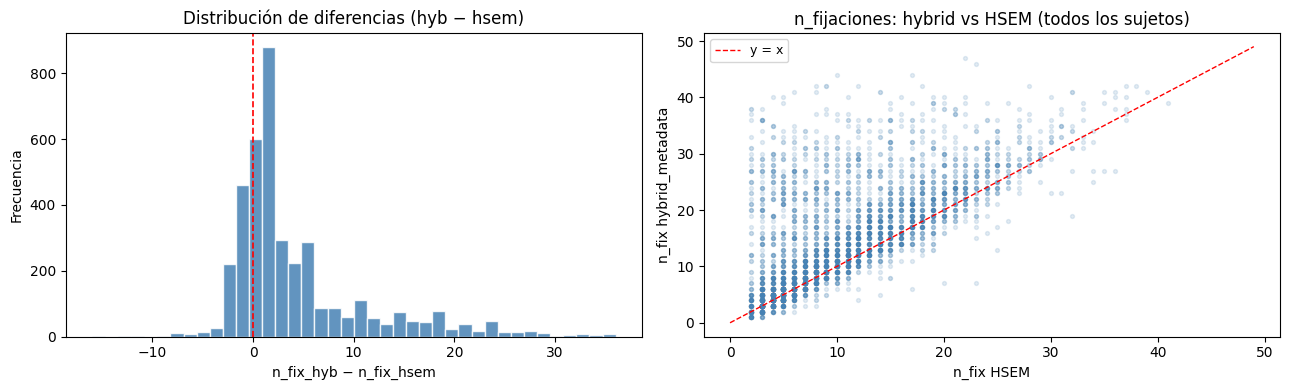


% trials con mismo n_fijaciones por sujeto:
         trials  coinciden   pct
subject                         
S105        101          4   4.0
S107        102          6   5.9
S113         98          7   7.1
S117        102          9   8.8
S106        102          9   8.8
S101        101          9   8.9
S111        100          9   9.0
S109        101         10   9.9
S102        101         10   9.9
S108         90          9  10.0
373490      100         10  10.0
712871       99         10  10.1
S115         99         12  12.1
200877      101         13  12.9
963607      102         14  13.7
S119         97         14  14.4
305138      101         15  14.9
248301      100         15  15.0
501896      101         16  15.8
419760      101         16  15.8
533569       99         16  16.2
179678      102         17  16.7
S114        102         17  16.7
848643      102         17  16.7
862513      102         17  16.7
S118        101         17  16.8
286470      101         18  17.

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma de diferencias
axes[0].hist(df_all['diff'], bins=40, color='steelblue', alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='red', linewidth=1.2, linestyle='--')
axes[0].set_title('Distribución de diferencias (hyb − hsem)')
axes[0].set_xlabel('n_fix_hyb − n_fix_hsem')
axes[0].set_ylabel('Frecuencia')

# Scatter n_hyb vs n_hsem
axes[1].scatter(df_all['n_hsem'], df_all['n_hyb'], alpha=0.15, s=8, color='steelblue')
lim = max(df_all['n_hyb'].max(), df_all['n_hsem'].max()) + 2
axes[1].plot([0, lim], [0, lim], 'r--', linewidth=1, label='y = x')
axes[1].set_xlabel('n_fix HSEM')
axes[1].set_ylabel('n_fix hybrid_metadata')
axes[1].set_title('n_fijaciones: hybrid vs HSEM (todos los sujetos)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Resumen por sujeto: % de trials que coinciden
print('\n% trials con mismo n_fijaciones por sujeto:')
subj_pct = (df_all.groupby('subject')['coincide']
            .agg(trials='count', coinciden='sum')
            .assign(pct=lambda d: (100 * d['coinciden'] / d['trials']).round(1))
            .sort_values('pct'))
print(subj_pct.to_string())

---
## 5. Outliers por feature: ¿vienen de las últimas fijaciones?

Hipótesis: los valores extremos (outliers) de cada feature corresponden a las últimas fijaciones
del trial, cuando el sujeto ya encontró (o resignó) el target y el movimiento ocular es errático.

- **Outlier**: valor fuera de `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]` (global por feature).
- **Posición relativa**: `fixation / (n_fix_trial − 1)` → 0 = primera, 1 = última.
- **Tercil**: primera tercera parte / mitad / última tercera parte del scanpath.

In [16]:
from pathlib import Path

FEATURES_DAM = Path('../Features_Damian')

def cargar_features_con_posicion(features_path):
    rows = []
    for img_dir in sorted(Path(features_path).iterdir()):
        if not img_dir.is_dir(): continue
        imagen = img_dir.name + '.jpg'
        for subj_dir in sorted(img_dir.iterdir()):
            jp = subj_dir / 'features.json'
            if not jp.exists(): continue
            with open(jp) as f: data = json.load(f)
            n = len(data['fijaciones'])
            for fij in data['fijaciones']:
                rows.append({
                    'imagen': imagen, 'sujeto': subj_dir.name,
                    'n_fix_trial': n, **fij
                })
    df = pd.DataFrame(rows)
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='ignore')
    df['pos_rel'] = df['fixation'] / (df['n_fix_trial'] - 1).clip(lower=1)
    df['tercil']  = pd.cut(df['pos_rel'], bins=[0, 1/3, 2/3, 1.0],
                           labels=['primera', 'media', 'última'], include_lowest=True)
    return df

df_feat = cargar_features_con_posicion(FEATURES_DAM)

META = {'imagen','sujeto','n_fix_trial','fixation','fix_y','fix_x',
        'modelo_fix_y','modelo_fix_x','pos_rel','tercil'}
FEAT_COLS = [c for c in df_feat.columns
             if c not in META and pd.api.types.is_numeric_dtype(df_feat[c])]

print(f'Fijaciones totales : {len(df_feat):,}')
print(f'Features analizadas: {len(FEAT_COLS)}')
print(f'Distribución por tercil:')
print(df_feat['tercil'].value_counts().sort_index().to_string())

Fijaciones totales : 61,252
Features analizadas: 25
Distribución por tercil:
tercil
primera    21944
media      18888
última     20420


/var/folders/8f/d2fjq2v97mj17hpklrr_c6yw0000gn/T/ipykernel_41203/1801717175.py:22: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


In [17]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def outlier_mask(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)

# Tabla: % outliers por tercil para cada feature
rows_out = []
for feat in FEAT_COLS:
    s = df_feat[feat].dropna()
    mask = outlier_mask(s)
    df_f = df_feat.loc[s.index].copy()
    df_f['is_outlier'] = mask
    pct = df_f.groupby('tercil', observed=True)['is_outlier'].mean() * 100
    rows_out.append({'feature': feat,
                     'pct_primera': pct.get('primera', np.nan),
                     'pct_media':   pct.get('media',   np.nan),
                     'pct_última':  pct.get('última',  np.nan),
                     'pct_total':   mask.mean() * 100})

df_out = pd.DataFrame(rows_out).set_index('feature')
df_out['ratio_ult_pri'] = df_out['pct_última'] / df_out['pct_primera'].clip(lower=0.01)

print('% outliers por tercil del scanpath (ordenado por ratio última/primera):')
print(df_out.sort_values('ratio_ult_pri', ascending=False).round(2).to_string())

% outliers por tercil del scanpath (ordenado por ratio última/primera):
                                 pct_primera  pct_media  pct_última  pct_total  ratio_ult_pri
feature                                                                                      
distancia_pixels                        0.11       0.71        0.85       0.52           7.77
distancia_grilla                        0.11       0.71        0.85       0.52           7.77
evidencia_visual                        3.19       5.72       13.01       7.24           4.08
competencia_ratio_segundo_mayor         6.33      14.32       25.42      15.16           4.01
competencia_ratio_mayor                 6.36      14.07       25.17      15.01           3.96
eig_optimo                              6.36      14.07       25.17      15.01           3.96
competencia_fp_media                    3.97       6.85       15.67       8.76           3.95
entropia_posterior                      6.84      14.67       25.89      15.60    

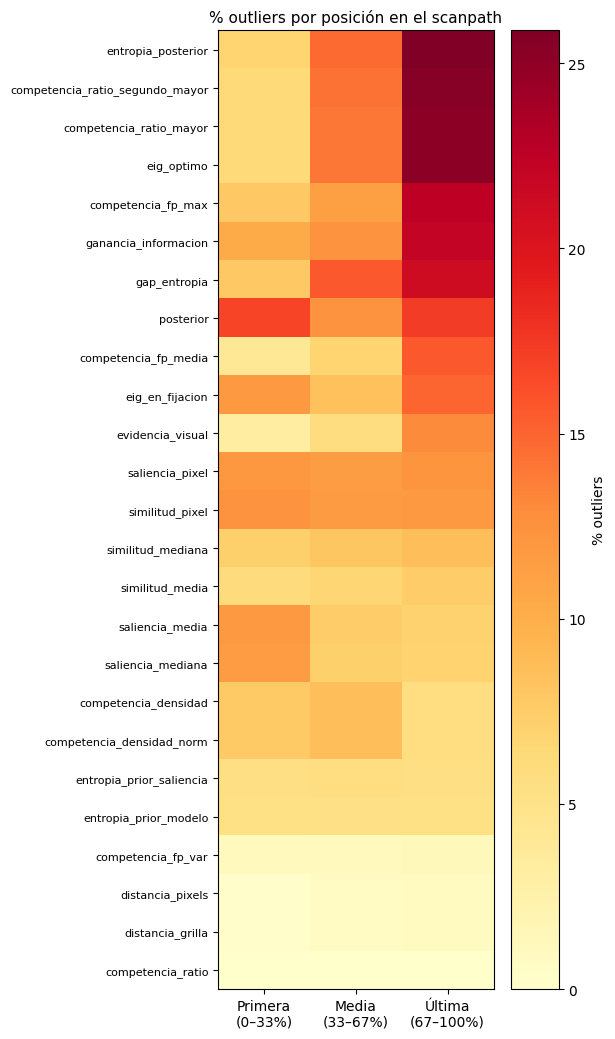

In [18]:
# Heatmap: features × tercil
heat = df_out[['pct_primera','pct_media','pct_última']].sort_values('pct_última', ascending=False)

fig, ax = plt.subplots(figsize=(6, len(FEAT_COLS) * 0.38 + 1))
im = ax.imshow(heat.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Primera\n(0–33%)', 'Media\n(33–67%)', 'Última\n(67–100%)'])
ax.set_yticks(range(len(heat)))
ax.set_yticklabels(heat.index, fontsize=8)
plt.colorbar(im, ax=ax, label='% outliers')
ax.set_title('% outliers por posición en el scanpath', fontsize=11)
plt.tight_layout()
plt.show()

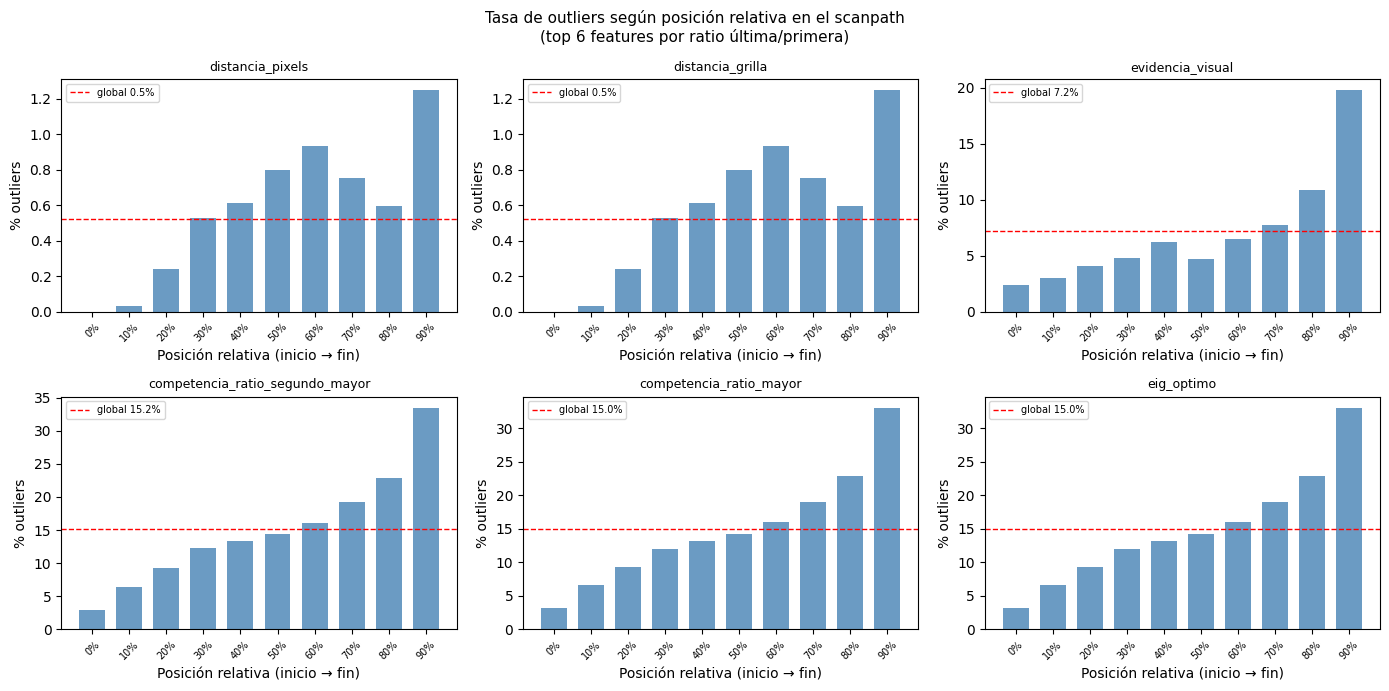

In [19]:
# Tasa de outliers como función continua de pos_rel (10 bins)
# Features con mayor ratio última/primera
top_feats = df_out.sort_values('ratio_ult_pri', ascending=False).head(6).index.tolist()

bins_pos = np.linspace(0, 1, 11)
labels_pos = [f'{int(b*100)}' for b in bins_pos[:-1]]

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=False)
fig.suptitle('Tasa de outliers según posición relativa en el scanpath\n(top 6 features por ratio última/primera)',
             fontsize=11)

for ax, feat in zip(axes.flat, top_feats):
    s = df_feat[feat].dropna()
    mask = outlier_mask(s)
    df_f = df_feat.loc[s.index].copy()
    df_f['is_outlier'] = mask
    df_f['bin_pos'] = pd.cut(df_f['pos_rel'], bins=bins_pos, labels=labels_pos, include_lowest=True)
    tasa = df_f.groupby('bin_pos', observed=True)['is_outlier'].mean() * 100

    ax.bar(range(len(tasa)), tasa.values, color='steelblue', alpha=0.8, width=0.7)
    ax.axhline(df_out.loc[feat, 'pct_total'], color='red', linestyle='--',
               linewidth=1, label=f'global {df_out.loc[feat, "pct_total"]:.1f}%')
    ax.set_xticks(range(len(tasa)))
    ax.set_xticklabels([f'{int(b*100)}%' for b in bins_pos[:-1]], fontsize=7, rotation=45)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('Posición relativa (inicio → fin)')
    ax.set_ylabel('% outliers')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

ValueError: zero-size array to reduction operation minimum which has no identity

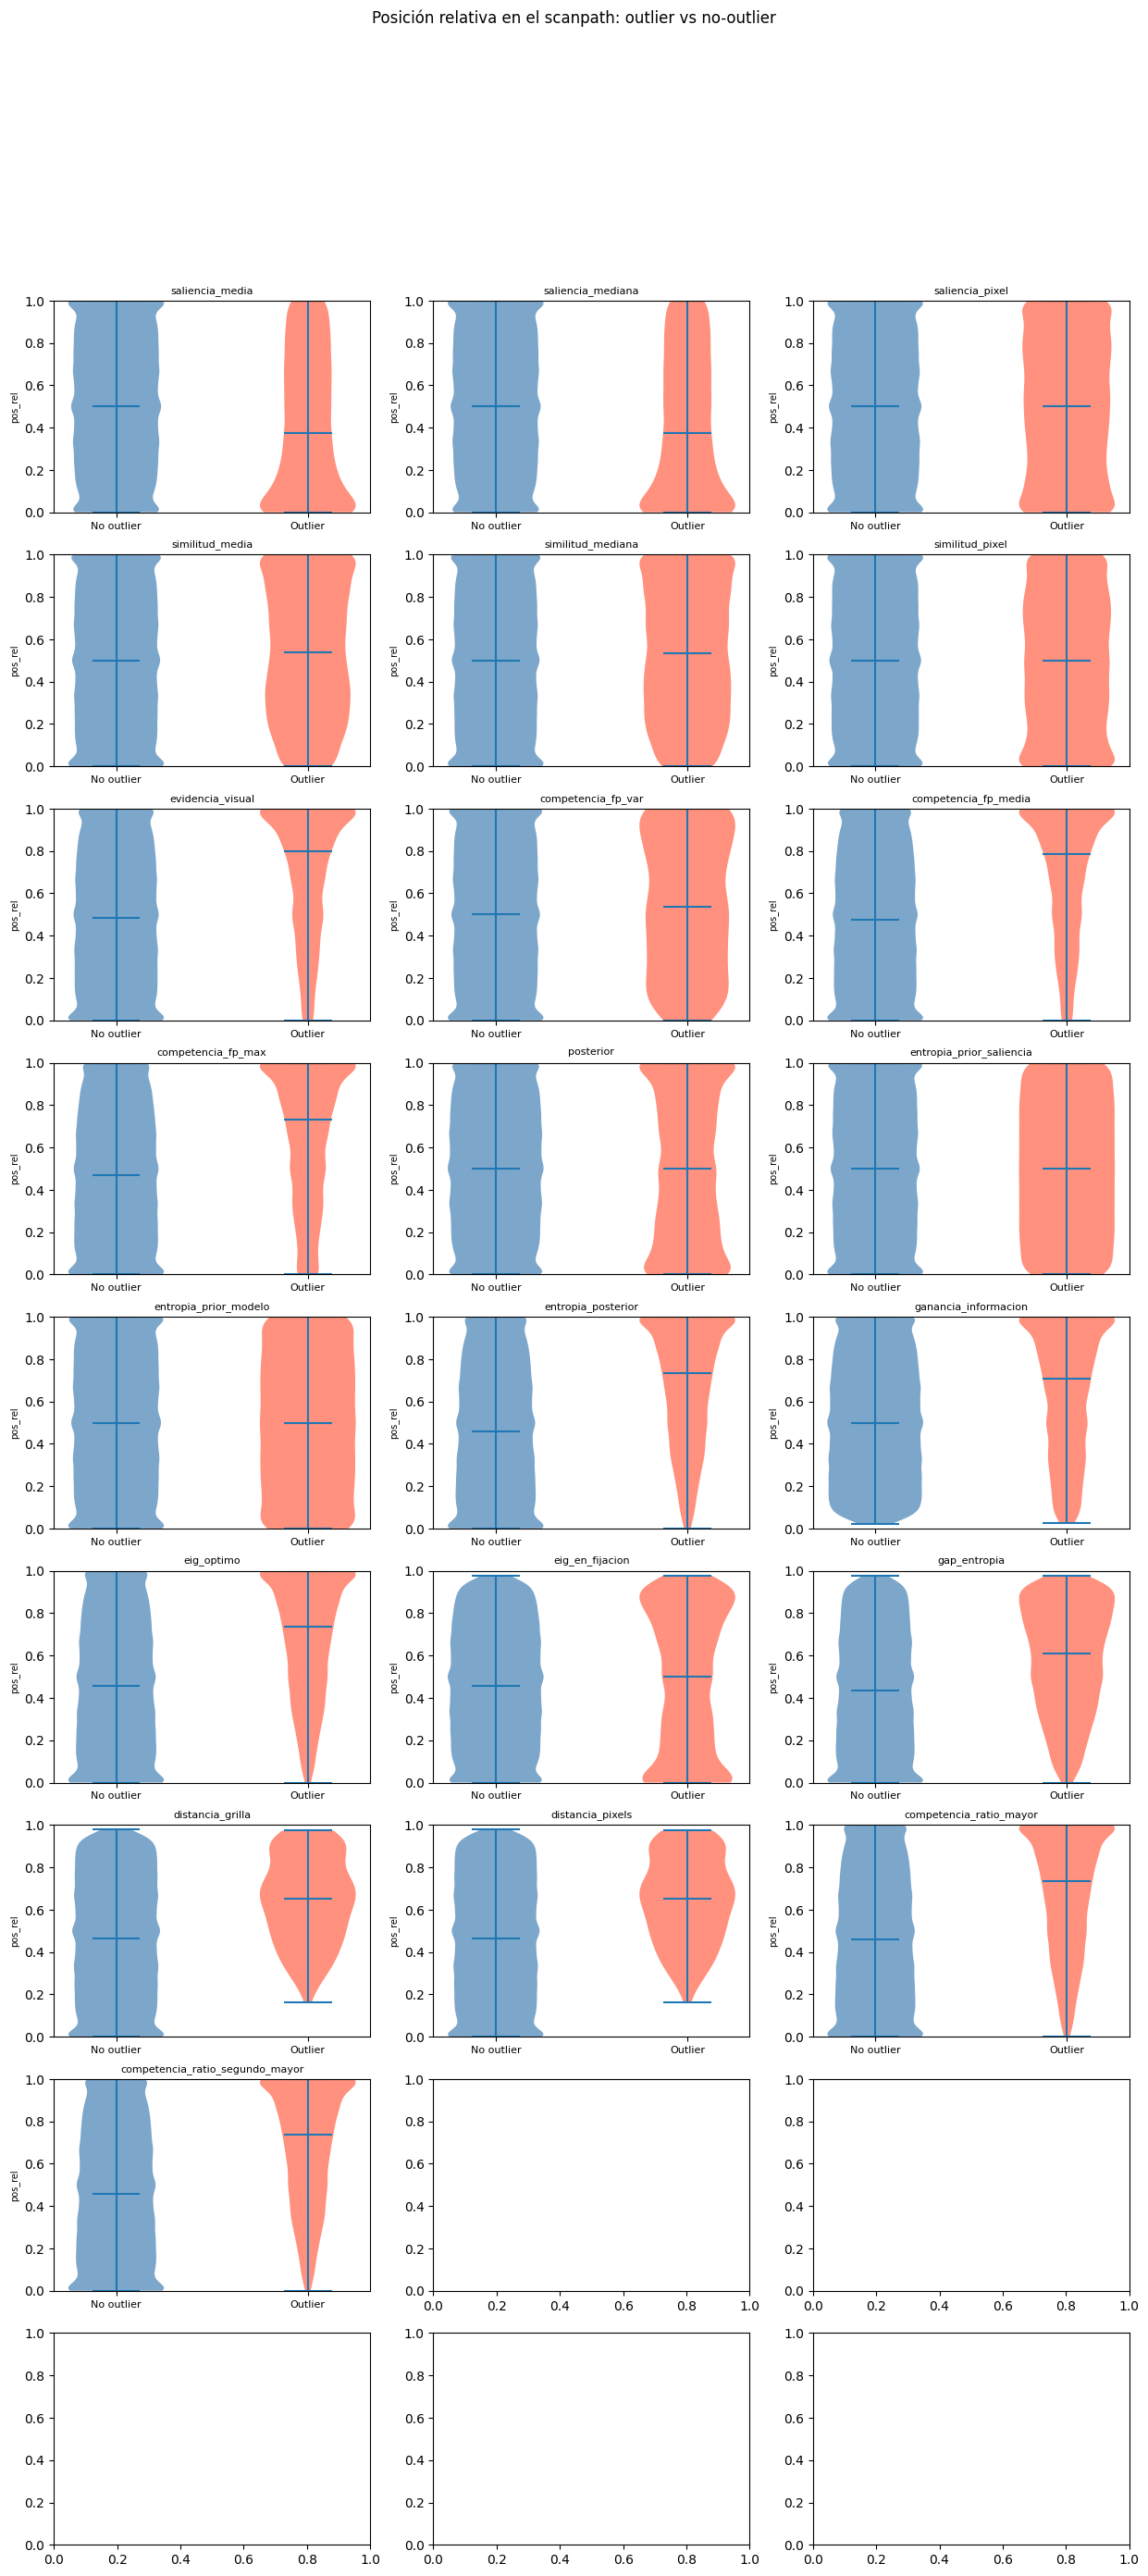

In [21]:
# Violin: distribución de pos_rel para outlier vs no-outlier en cada feature
n_cols = 3
n_rows = -(-len(FEAT_COLS) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
fig.suptitle('Posición relativa en el scanpath: outlier vs no-outlier', fontsize=12)

for ax, feat in zip(axes.flat, FEAT_COLS):
    s = df_feat[feat].dropna()
    mask = outlier_mask(s)
    df_f = df_feat.loc[s.index].copy()
    df_f['is_outlier'] = mask

    groups = [df_f.loc[~mask, 'pos_rel'].values,
              df_f.loc[ mask, 'pos_rel'].values]
    parts = ax.violinplot(groups, positions=[0, 1], showmedians=True)
    for pc, color in zip(parts['bodies'], ['steelblue', 'tomato']):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No outlier', 'Outlier'], fontsize=8)
    ax.set_ylabel('pos_rel', fontsize=7)
    ax.set_title(feat, fontsize=8)
    ax.set_ylim(0, 1)

for ax in axes.flat[len(FEAT_COLS):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

---
## 6. Análisis de la primera fijación: ¿Damián siempre pierde la primera de Gonza?

Para cada par (sujeto, imagen) en común, se compara la primera fijación de Gonza (HSEM)
con la primera de Damián (hybrid_metadata).

**Hipótesis**: Gonza incluye una fijación de inicio de trial (previa al search activo)
que Damián filtra con `phase=='vs'`. Esa fijación sería la primera en HSEM y no aparecería en hybrid.

**Método**: distancia euclídea (px) entre:
- `d0` = Damián[0] vs Gonza[0]
- `d1` = Damián[0] vs Gonza[1]

Si `d1 << d0`, el patrón es "Gonza tiene 1 fijación extra al inicio".

In [22]:
THR = 30   # umbral en px para considerar dos fijaciones "la misma"

rows_fix1 = []
for subj in common:
    sp_h = all_sp[subj]['hyb']
    sp_s = all_sp[subj]['hsem']
    for img in sorted(set(sp_h.keys()) & set(sp_s.keys())):
        xd, yd = sp_h[img]['X'], sp_h[img]['Y']   # Damián
        xg, yg = sp_s[img]['X'], sp_s[img]['Y']   # Gonza

        if len(xd) == 0 or len(xg) == 0:
            continue

        d0 = np.sqrt((xd[0] - xg[0])**2 + (yd[0] - yg[0])**2)
        d1 = np.sqrt((xd[0] - xg[1])**2 + (yd[0] - yg[1])**2) if len(xg) > 1 else np.nan

        # Clasificación
        if d0 <= THR:
            categoria = 'alineados'
        elif not np.isnan(d1) and d1 <= THR:
            categoria = 'damian_falta_1'
        else:
            categoria = 'otro'

        rows_fix1.append({
            'subject'    : subj,
            'image'      : img,
            'n_dam'      : len(xd),
            'n_gon'      : len(xg),
            'diff_n'     : len(xd) - len(xg),
            'd0'         : round(d0, 1),
            'd1'         : round(d1, 1) if not np.isnan(d1) else np.nan,
            'categoria'  : categoria,
            # Coordenadas de la primera fijación de Gonza
            'gon_x0'     : round(xg[0], 1),
            'gon_y0'     : round(yg[0], 1),
        })

df_fix1 = pd.DataFrame(rows_fix1)

print(f'Pares analizados: {len(df_fix1):,}')
print()
print('Categorías:')
cats = df_fix1['categoria'].value_counts()
for cat, cnt in cats.items():
    print(f'  {cat:<20}: {cnt:,}  ({100*cnt/len(df_fix1):.1f}%)')


Pares analizados: 3,915

Categorías:
  damian_falta_1      : 3,135  (80.1%)
  alineados           : 497  (12.7%)
  otro                : 283  (7.2%)


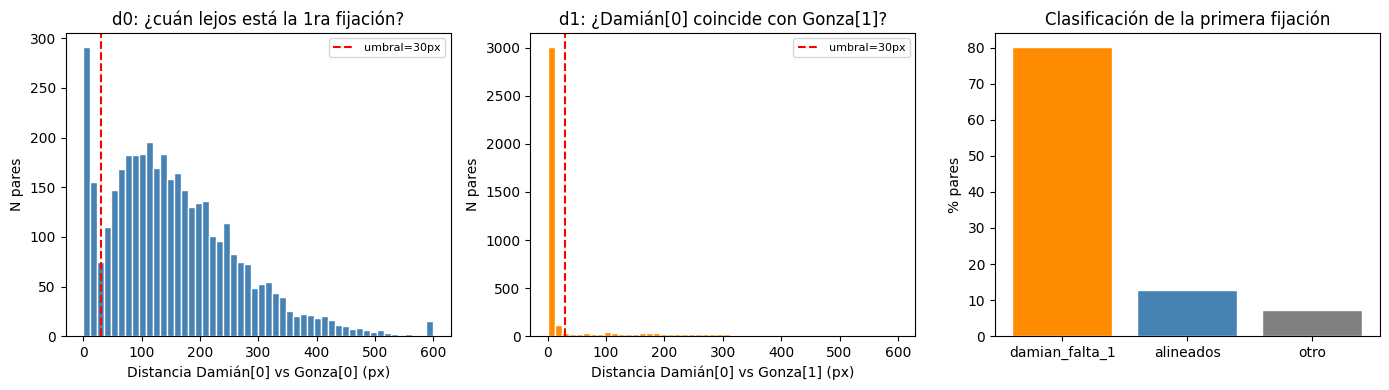

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: distribución de d0 (distancia entre primeras fijaciones)
ax = axes[0]
ax.hist(df_fix1['d0'].clip(upper=600), bins=50, color='steelblue', edgecolor='white')
ax.axvline(THR, color='red', lw=1.5, ls='--', label=f'umbral={THR}px')
ax.set_xlabel('Distancia Damián[0] vs Gonza[0] (px)')
ax.set_ylabel('N pares')
ax.set_title('d0: ¿cuán lejos está la 1ra fijación?')
ax.legend(fontsize=8)

# Panel 2: distribución de d1 (distancia entre Damián[0] y Gonza[1])
ax = axes[1]
d1_vals = df_fix1['d1'].dropna().clip(upper=600)
ax.hist(d1_vals, bins=50, color='darkorange', edgecolor='white')
ax.axvline(THR, color='red', lw=1.5, ls='--', label=f'umbral={THR}px')
ax.set_xlabel('Distancia Damián[0] vs Gonza[1] (px)')
ax.set_ylabel('N pares')
ax.set_title('d1: ¿Damián[0] coincide con Gonza[1]?')
ax.legend(fontsize=8)

# Panel 3: % por categoría
ax = axes[2]
cats = df_fix1['categoria'].value_counts()
colors = {'alineados': 'steelblue', 'damian_falta_1': 'darkorange', 'otro': 'gray'}
ax.bar(cats.index, 100 * cats.values / len(df_fix1),
       color=[colors[c] for c in cats.index], edgecolor='white')
ax.set_ylabel('% pares')
ax.set_title('Clasificación de la primera fijación')

plt.tight_layout()
plt.show()


Distancia de Gonza[0] al centro de imagen (640, 512):
  Media : 100.5 px
  Mediana: 67.6 px
  < 100px: 65.8%
  < 200px: 87.2%

Gonza[0] promedio:  X=622.2 px,  Y=491.4 px


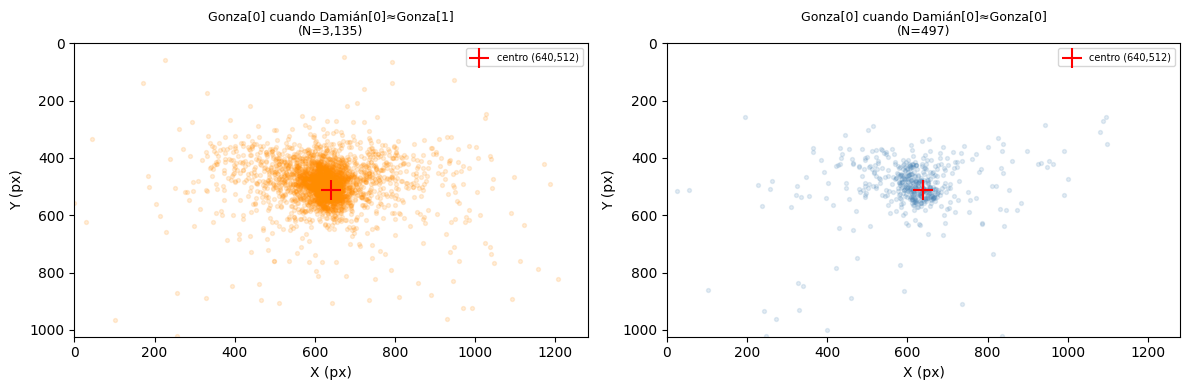

In [24]:
# ¿Cuáles son las coordenadas de la primera fijación de Gonza?
# Si es una fijación de inicio de trial, debería estar cerca del centro de la imagen (640, 512)
IMAGE_CENTER_X, IMAGE_CENTER_Y = 1280 / 2, 1024 / 2

dist_centro_gon = np.sqrt(
    (df_fix1['gon_x0'] - IMAGE_CENTER_X)**2 +
    (df_fix1['gon_y0'] - IMAGE_CENTER_Y)**2
)

print(f'Distancia de Gonza[0] al centro de imagen ({IMAGE_CENTER_X:.0f}, {IMAGE_CENTER_Y:.0f}):')
print(f'  Media : {dist_centro_gon.mean():.1f} px')
print(f'  Mediana: {dist_centro_gon.median():.1f} px')
print(f'  < 100px: {(dist_centro_gon < 100).mean()*100:.1f}%')
print(f'  < 200px: {(dist_centro_gon < 200).mean()*100:.1f}%')
print()
print(f'Gonza[0] promedio:  X={df_fix1["gon_x0"].mean():.1f} px,  Y={df_fix1["gon_y0"].mean():.1f} px')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter de Gonza[0] para 'damian_falta_1' — ¿están cerca del centro?
for ax, cat, color, title in [
    (axes[0], 'damian_falta_1', 'darkorange', 'Gonza[0] cuando Damián[0]≈Gonza[1]'),
    (axes[1], 'alineados',      'steelblue',  'Gonza[0] cuando Damián[0]≈Gonza[0]'),
]:
    sub = df_fix1[df_fix1['categoria'] == cat]
    ax.scatter(sub['gon_x0'], sub['gon_y0'], alpha=0.15, s=8, color=color)
    ax.scatter(IMAGE_CENTER_X, IMAGE_CENTER_Y, marker='+', s=200, color='red', zorder=5,
               label=f'centro ({IMAGE_CENTER_X:.0f},{IMAGE_CENTER_Y:.0f})')
    ax.set_xlim(0, 1280); ax.set_ylim(1024, 0)
    ax.set_xlabel('X (px)'); ax.set_ylabel('Y (px)')
    ax.set_title(f'{title}\n(N={len(sub):,})', fontsize=9)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()


In [25]:
# ¿El patrón varía por sujeto?
subj_cats = (df_fix1.groupby(['subject', 'categoria'])
             .size()
             .unstack(fill_value=0)
             .assign(total=lambda d: d.sum(axis=1)))

for cat in ['alineados', 'damian_falta_1', 'otro']:
    if cat in subj_cats.columns:
        subj_cats[f'pct_{cat}'] = (100 * subj_cats[cat] / subj_cats['total']).round(1)

cols_show = ['total'] + [c for c in subj_cats.columns if c.startswith('pct_')]
print('% de casos por sujeto:')
print(subj_cats[cols_show].sort_values('pct_damian_falta_1', ascending=False).to_string())


% de casos por sujeto:
categoria  total  pct_alineados  pct_damian_falta_1  pct_otro
subject                                                      
389622       100            2.0                97.0       1.0
S103          98            5.1                92.9       2.0
S113          98            6.1                91.8       2.0
S116         101            5.0                90.1       5.0
533569        99            8.1                89.9       2.0
677251       102           10.8                89.2       0.0
244108       100           11.0                89.0       0.0
286470       101           10.9                88.1       1.0
619958       100           11.0                88.0       1.0
S101         101            8.9                87.1       4.0
S111         100           11.0                86.0       3.0
373490       100           14.0                86.0       0.0
862513       102           14.7                85.3       0.0
963607       102           14.7                